<!-- Cell purpose: Introduce the 800 nm unembryonated egg analysis notebook. -->

# 800 nm Unembryonated Egg Analysis (CW vs Pulsed)

This notebook analyzes unembryonated eggs, starting with control datasets in chronological order:

- `2024-03-04`
- `2024-03-20`
- `2025-06-12`

Control section includes:
- QC summary per control date
- Raincloud timing plots across stages (`2c`, `4c`, `bean`, `move`) for `outcome == l3_reached`
- Per-stage significance testing across control dates


In [1]:
# Import libraries and configure notebook settings

from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import ptitprince as pt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style="whitegrid", context="talk")

CSV_PATH = "master_csv/01_master_unembryonated.csv"
CONTROL_DATES = [
    pd.Timestamp("2024-03-04"),
    pd.Timestamp("2024-03-20"),
    pd.Timestamp("2025-06-12"),
]
PLOTS_DIR = Path("800nm/unembryonated/plots/")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = Path("800nm/unembryonated/tables/")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
    

In [2]:
# Define helper functions for file lookup and data preparation

def resolve_csv_path(raw_path: str) -> Path:
    raw = Path(raw_path)
    stripped = Path(str(raw_path).replace("LIA-STH-Repo/", "", 1))

    start = Path.cwd().resolve()
    search_bases = [start, *start.parents]

    candidates = [raw, stripped]
    for base in search_bases:
        candidates.append(base / raw)
        candidates.append(base / stripped)

    seen = set()
    for cand in candidates:
        key = str(cand)
        if key in seen:
            continue
        seen.add(key)
        if cand.exists():
            return cand.resolve()

    raise FileNotFoundError(f"CSV not found. Tried: {[str(c) for c in candidates]}")


def to_snake_or_nan(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    s = re.sub(r"[^0-9a-zA-Z]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else np.nan


In [3]:
# Strict load/clean

csv_file = resolve_csv_path(CSV_PATH)
df = pd.read_csv(csv_file)

unnamed = [c for c in df.columns if c.lower().startswith("unnamed")]
if unnamed:
    df = df.drop(columns=unnamed)

if "well_#" in df.columns:
    df = df.rename(columns={"well_#": "well_id"})

text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
for col in text_cols:
    s = df[col].astype("string").str.strip()
    s = s.replace({"NA": pd.NA, "na": pd.NA, "": pd.NA, "None": pd.NA, "none": pd.NA}, regex=False)
    df[col] = s

df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
for col in ["system", "regime", "outcome", "flags"]:
    df[col] = df[col].map(to_snake_or_nan)

for col in ["control", "t_start_h", "t_2c_h", "t_4c_h", "t_bean_h", "t_move_h"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Loaded: {csv_file}")
print(f"Rows: {len(df)}")


Loaded: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/master_csv/01_master_unembryonated.csv
Rows: 866


In [4]:
# Subset controls for all three dates (chronological), then QC outcomes

ctrl_sub = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()

qc_counts = (
    ctrl_sub.groupby(["start_date", "outcome"], dropna=False)
    .size()
    .rename("n")
    .reset_index()
    .sort_values(["start_date", "outcome"], na_position="last")
)
qc_counts["start_date"] = qc_counts["start_date"].dt.date.astype(str)
display(qc_counts)

summary_rows = []
for cdate in CONTROL_DATES:
    sub = ctrl_sub[ctrl_sub["start_date"] == cdate]
    summary_rows.append(
        {
            "date": str(cdate.date()),
            "n_total": int(len(sub)),
            "n_l3_reached": int((sub["outcome"] == "l3_reached").sum()),
            "n_degenerated": int((sub["outcome"] == "degenerated").sum()),
        }
    )

qc_summary = pd.DataFrame(summary_rows)
display(qc_summary)

qc_counts_csv = TABLES_DIR / "control_qc_counts_by_date_outcome.csv"
qc_summary_csv = TABLES_DIR / "control_qc_summary_three_dates.csv"
qc_counts.to_csv(qc_counts_csv, index=False)
qc_summary.to_csv(qc_summary_csv, index=False)
print(f"Saved: {qc_counts_csv.resolve()}")
print(f"Saved: {qc_summary_csv.resolve()}")


,start_date,outcome,n
0,2024-03-04,degenerated,2
1,2024-03-04,l3_reached,35
2,2024-03-20,l3_reached,24
3,2025-06-12,degenerated,2
4,2025-06-12,l3_reached,34


,date,n_total,n_l3_reached,n_degenerated
0,2024-03-04,37,35,2
1,2024-03-20,24,24,0
2,2025-06-12,36,34,2


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/control_qc_counts_by_date_outcome.csv
Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/control_qc_summary_three_dates.csv


<!-- Cell purpose: Introduce the control raincloud comparison section. -->

## Rainclouds for three control dates in chronological order (shared x-axis; half-violin style)

Figure: Raincloud plots of control embryonation timing by stage across three independent control dates. Panels correspond to 2024-03-04, 2024-03-20, and 2025-06-12 (one date per row), with a shared x-axis for direct cross-date comparison. The x-axis is elapsed time in hours from t_start_h, computed per stage as dt_stage = t_stage_h - t_start_h; the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). Each raincloud combines distribution shape (half-violin), spread and central tendency (box/IQR), and individual observations, with bold labels indicating stage-specific medians. Only control eggs with outcome == l3_reached are included; stage-wise sample sizes can differ because missing stage timestamps are excluded.


/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):
/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default a

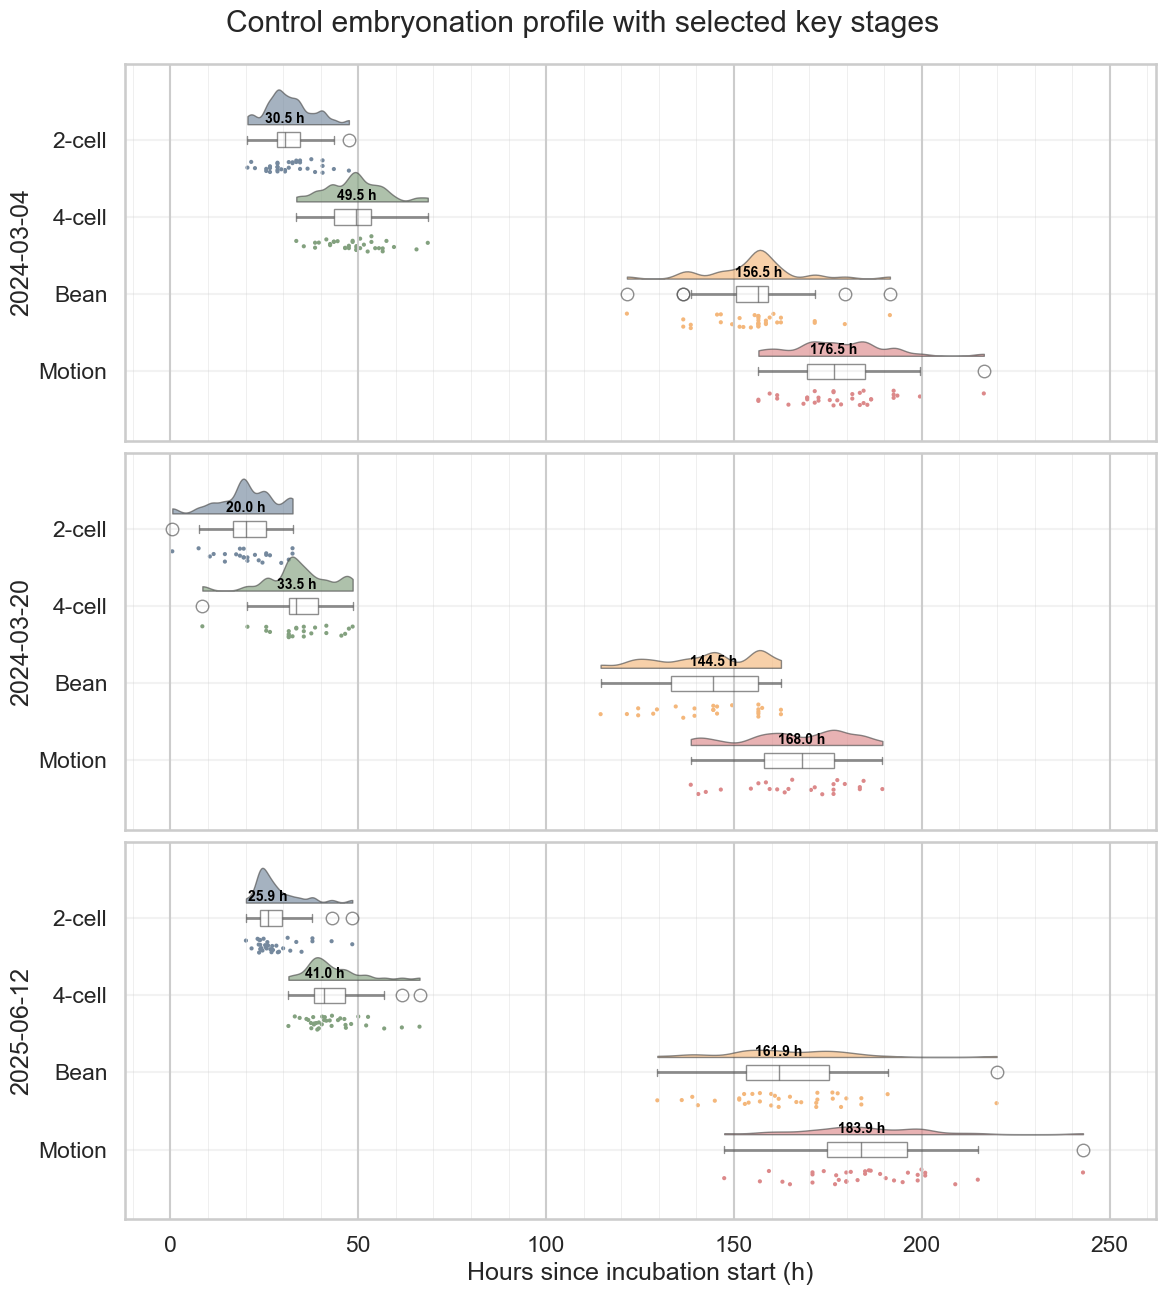

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/plots/raincloud_controls_three_dates_shared_x.png


In [5]:
# Raincloud plots of control embryonation timing by stage across three independent control dates

fig_caption_controls_three_dates = (
    "Figure: Raincloud plots of control embryonation timing by stage across three independent control dates. "
    "Panels correspond to 2024-03-04, 2024-03-20, and 2025-06-12 (one date per row), with a shared x-axis "
    "for direct cross-date comparison. The x-axis is elapsed time in hours from t_start_h, computed per stage "
    "as dt_stage = t_stage_h - t_start_h; the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). "
    "Each raincloud combines distribution shape (half-violin), spread and central tendency (box/IQR), and "
    "individual observations, with bold labels indicating stage-specific medians. Only control eggs with "
    "outcome == l3_reached are included; stage-wise sample sizes can differ because missing stage timestamps "
    "are excluded."
)
print(fig_caption_controls_three_dates)


control_dates = CONTROL_DATES.copy()

try:
    stage_order
except NameError:
    stage_order = ["2-cell", "4-cell", "Bean", "Motion"]
stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}

palette_ctrl = ["#75899e", "#83a17f", "#f4b77b", "#dc898a"]
label_offset_cat = -0.18  # move labels further above boxes
pad_top_cat = 0.12 * len(stage_order)      # 12% of stage span
pad_bottom_cat = 0.1 * len(stage_order)   # 15% of stage span


def make_plot_df_for_date(ctrl_date: pd.Timestamp) -> pd.DataFrame:
    sub = df[(df["control"] == 1) & (df["start_date"] == ctrl_date)].copy()
    if sub.empty:
        return sub
    for s in ["2c", "4c", "bean", "move"]:
        sub[f"dt_{s}"] = sub[f"t_{s}_h"] - sub["t_start_h"]
    sub = sub[sub["outcome"] == "l3_reached"].copy()
    long = (
        sub.melt(
            id_vars=["egg_uid", "well_id", "outcome"],
            value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
            var_name="stage",
            value_name="dt_h",
        )
        .dropna(subset=["dt_h"])
        .copy()
    )
    long["stage"] = long["stage"].map(stage_label_map)
    long["stage"] = pd.Categorical(long["stage"], categories=stage_order, ordered=True)
    return long

fig, axes = plt.subplots(len(control_dates), 1, figsize=(12, 14), sharex=True)
if len(control_dates) == 1:
    axes = [axes]

max_dt = 0
for ax, cdate in zip(axes, control_dates):
    plot_df = make_plot_df_for_date(cdate)
    if plot_df.empty:
        ax.text(0.5, 0.5, f"No data for {cdate.date()}", ha="center", va="center")
        continue
    max_dt = max(max_dt, plot_df["dt_h"].max())

    pt.RainCloud(
        x="stage",
        y="dt_h",
        data=plot_df,
        orient="h",
        order=stage_order,
        palette=palette_ctrl,
        bw=0.2,
        width_viol=0.9,
        width_box=0.2,
        move=0.35,
        alpha=0.65,
        dodge=False,
        pointplot=False,
        ax=ax,
    )

    medians = plot_df.groupby("stage", observed=True)["dt_h"].median().reindex(stage_order)
    for y, (stage, med) in enumerate(medians.items()):
        ax.text(
            med,
            y + label_offset_cat,
            f"{med:.1f} h",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="black",
            zorder=6,
        )

    ax.set_ylabel(str(cdate.date()))
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)
    ax.set_ylim(-0.5 - pad_top_cat, len(stage_order) - 0.5 + pad_bottom_cat)
    ax.invert_yaxis()

axes[-1].set_xlabel("Hours since incubation start (h)")
for ax in axes[:-1]:
    ax.set_xlabel("")

for ax in axes:
    pad_left = max(5, 0.05 * max_dt) if max_dt > 0 else 5
    ax.set_xlim(left=-pad_left, right=max_dt * 1.08 if max_dt > 0 else None)

fig.suptitle("Control embryonation profile with selected key stages", y=0.93)
fig.tight_layout(rect=[0, 0, 1, 0.95], h_pad=0.5)

out_png = PLOTS_DIR / "raincloud_controls_three_dates_shared_x.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")



Figure: Grouped boxplot with strip overlay of control embryonation timing by stage and control date. Main groups are developmental stages (2-cell, 4-cell, Bean, Motion), and subgroups within each stage are control dates (2024-03-04, 2024-03-20, 2025-06-12). The x-axis is elapsed time in hours from t_start_h, computed per stage as dt_stage = t_stage_h - t_start_h. Colored boxplots summarize median and IQR (outliers hidden), and overlaid jittered points show individual egg-level observations for each stage/date subgroup. Only control eggs with outcome == l3_reached are included; stage-wise and date-wise sample sizes can differ because missing stage timestamps are excluded.


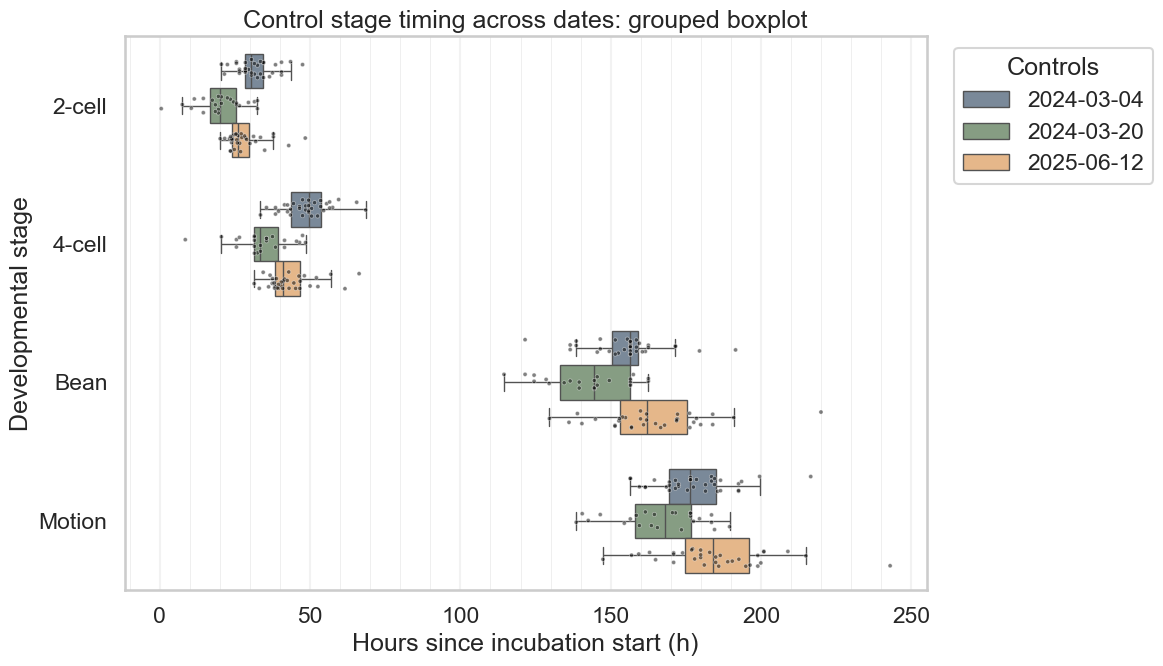

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/plots/boxplot_controls_three_dates_by_stage.png


In [6]:
# Grouped boxplot with strip overlay of control embryonation timing by stage and control date

fig_caption_controls_boxplot = (
    "Figure: Grouped boxplot with strip overlay of control embryonation timing by stage and control date. "
    "Main groups are developmental stages (2-cell, 4-cell, Bean, Motion), and subgroups within each stage "
    "are control dates (2024-03-04, 2024-03-20, 2025-06-12). The x-axis is elapsed time in hours from "
    "t_start_h, computed per stage as dt_stage = t_stage_h - t_start_h. Colored boxplots summarize median "
    "and IQR (outliers hidden), and overlaid jittered points show individual egg-level observations for each "
    "stage/date subgroup. Only control eggs with outcome == l3_reached are included; stage-wise and date-wise "
    "sample sizes can differ because missing stage timestamps are excluded."
)
print(fig_caption_controls_boxplot)

try:
    stage_order
except NameError:
    stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}

control_date_order = ["2024-03-04", "2024-03-20", "2025-06-12"]
palette = {
    "2024-03-04": "#75899e",
    "2024-03-20": "#83a17f",
    "2025-06-12": "#f4b77b",
}

point_palette = {
    "2024-03-04": "#000000",
    "2024-03-20": "#060606",
    "2025-06-12": "#000000",
}

control_box_src = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()
for s in ["2c", "4c", "bean", "move"]:
    control_box_src[f"dt_{s}"] = control_box_src[f"t_{s}_h"] - control_box_src["t_start_h"]

control_box_src = control_box_src[control_box_src["outcome"] == "l3_reached"].copy()
control_box_src["control_date"] = pd.to_datetime(control_box_src["start_date"], errors="coerce").dt.date.astype(str)

control_box_long = (
    control_box_src.melt(
        id_vars=["egg_uid", "well_id", "control_date", "outcome"],
        value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
        var_name="stage",
        value_name="dt_h",
    )
    .dropna(subset=["dt_h"])
    .copy()
)

control_box_long["stage"] = control_box_long["stage"].map(stage_label_map)
control_box_long["stage"] = pd.Categorical(control_box_long["stage"], categories=stage_order, ordered=True)
control_box_long["control_date"] = pd.Categorical(
    control_box_long["control_date"],
    categories=control_date_order,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(
    data=control_box_long,
    x="dt_h",
    y="stage",
    hue="control_date",
    order=stage_order,
    hue_order=control_date_order,
    palette=palette,
    showfliers=False,
    linewidth=1.0,
    width=0.75,
    ax=ax,
)

sns.stripplot(
    data=control_box_long,
    x="dt_h",
    y="stage",
    hue="control_date",
    order=stage_order,
    hue_order=control_date_order,
    palette=point_palette,
    dodge=True,
    jitter=0.2,
    size=3,
    alpha=0.5,
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
)

ax.set_ylabel("Developmental stage")
ax.set_xlabel("Hours since incubation start (h)")
ax.set_title("Control stage timing across dates: grouped boxplot")
ax.grid(axis="x", alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

handles, labels = ax.get_legend_handles_labels()
seen = set()
uniq_handles = []
uniq_labels = []
for h, l in zip(handles, labels):
    if l in seen:
        continue
    seen.add(l)
    uniq_handles.append(h)
    uniq_labels.append(l)
ax.legend(uniq_handles, uniq_labels, title="Controls", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
out_png = PLOTS_DIR / "boxplot_controls_three_dates_by_stage.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")



<!-- Cell purpose: Introduce per-stage significance across control dates (only with l3_reached controls). -->

## Per-stage significance across control dates (only with l3_reached controls)

In [7]:
# Per-stage stats across control dates

from itertools import combinations
from scipy import stats

analysis_dates = CONTROL_DATES.copy()
alpha = 0.05


def holm_adjust(pvals: np.ndarray) -> np.ndarray:
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        candidate = pvals[idx] * (m - rank)
        running = max(running, candidate)
        adj[idx] = min(running, 1.0)
    return adj


def p_to_sig(p: float) -> str:
    if np.isnan(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


sub = df[(df["control"] == 1) & (df["start_date"].isin(analysis_dates))].copy()
for s in ["2c", "4c", "bean", "move"]:
    sub[f"dt_{s}"] = sub[f"t_{s}_h"] - sub["t_start_h"]
sub = sub[sub["outcome"] == "l3_reached"].copy()

long_all = (
    sub.melt(
        id_vars=["egg_uid", "well_id", "start_date", "outcome"],
        value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
        var_name="stage",
        value_name="dt_h",
    )
    .dropna(subset=["dt_h"])
    .copy()
)
long_all["stage"] = long_all["stage"].map(stage_label_map)
long_all["stage"] = pd.Categorical(long_all["stage"], categories=stage_order, ordered=True)

rows = []
date_labels = [str(d.date()) for d in analysis_dates]

for stage in stage_order:
    stage_df = long_all[long_all["stage"] == stage].copy()
    groups = [stage_df.loc[stage_df["start_date"] == d, "dt_h"].to_numpy(dtype=float) for d in analysis_dates]
    sizes = {str(d.date()): len(g) for d, g in zip(analysis_dates, groups)}

    if any(len(g) == 0 for g in groups):
        omnibus_test = "NA"
        omnibus_p = np.nan
        pair_method = "NA"
    else:
        normal_ok = True
        for g in groups:
            if len(g) < 3:
                normal_ok = False
                break
            if stats.shapiro(g).pvalue < alpha:
                normal_ok = False
                break

        if normal_ok:
            omnibus_test = "ANOVA"
            omnibus_p = float(stats.f_oneway(*groups).pvalue)
            pair_method = "Welch t-test"
        else:
            omnibus_test = "Kruskal-Wallis"
            omnibus_p = float(stats.kruskal(*groups).pvalue)
            pair_method = "Mann-Whitney U"

    pair_idxs = list(combinations(range(len(analysis_dates)), 2))
    raw_ps = []
    raw_stats = []
    pair_names = []

    for i, j in pair_idxs:
        g1, g2 = groups[i], groups[j]
        pair_names.append(f"{date_labels[i]} vs {date_labels[j]}")
        if len(g1) == 0 or len(g2) == 0:
            raw_stats.append(np.nan)
            raw_ps.append(np.nan)
            continue
        if pair_method == "Welch t-test":
            tst = stats.ttest_ind(g1, g2, equal_var=False, nan_policy="omit")
            raw_stats.append(float(tst.statistic))
            raw_ps.append(float(tst.pvalue))
        elif pair_method == "Mann-Whitney U":
            mw = stats.mannwhitneyu(g1, g2, alternative="two-sided")
            raw_stats.append(float(mw.statistic))
            raw_ps.append(float(mw.pvalue))
        else:
            raw_stats.append(np.nan)
            raw_ps.append(np.nan)

    raw_ps_arr = np.array(raw_ps, dtype=float)
    valid_mask = np.isfinite(raw_ps_arr)
    adj_ps = np.full_like(raw_ps_arr, np.nan)
    if valid_mask.any():
        adj_ps[valid_mask] = holm_adjust(raw_ps_arr[valid_mask])

    for comp, stat, p_raw, p_adj in zip(pair_names, raw_stats, raw_ps, adj_ps):
        rows.append(
            {
                "stage": stage,
                "n_2024-03-04": sizes["2024-03-04"],
                "n_2024-03-20": sizes["2024-03-20"],
                "n_2025-06-12": sizes["2025-06-12"],
                "omnibus_test": omnibus_test,
                "omnibus_p": omnibus_p,
                "pairwise_test": pair_method,
                "comparison": comp,
                "statistic": stat,
                "p_raw": p_raw,
                "p_holm": p_adj,
                "significant_0.05": bool(np.isfinite(p_adj) and p_adj < alpha),
                "sig": p_to_sig(p_adj),
            }
        )

results_df = pd.DataFrame(rows).sort_values(["stage", "comparison"]).reset_index(drop=True)

pd.set_option("display.precision", 4)
if "display" in globals():
    display(results_df)
else:
    print(results_df.to_string(index=False))

out_csv = TABLES_DIR / "control_stage_significance_three_dates.csv"
results_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,stage,n_2024-03-04,n_2024-03-20,n_2025-06-12,omnibus_test,omnibus_p,pairwise_test,comparison,statistic,p_raw,p_holm,significant_0.05,sig
0,2-cell,35,24,34,Kruskal-Wallis,3.1228e-07,Mann-Whitney U,2024-03-04 vs 2024-03-20,740.5000,7.6338e-07,2.2902e-06,True,***
1,2-cell,35,24,34,Kruskal-Wallis,3.1228e-07,Mann-Whitney U,2024-03-04 vs 2025-06-12,837.0000,3.7280e-03,3.7280e-03,True,**
2,2-cell,35,24,34,Kruskal-Wallis,3.1228e-07,Mann-Whitney U,2024-03-20 vs 2025-06-12,175.0000,2.4098e-04,4.8196e-04,True,***
3,4-cell,35,24,34,Kruskal-Wallis,3.8194e-08,Mann-Whitney U,2024-03-04 vs 2024-03-20,765.5000,9.8799e-08,2.9640e-07,True,***
4,4-cell,35,24,34,Kruskal-Wallis,3.8194e-08,Mann-Whitney U,2024-03-04 vs 2025-06-12,868.5000,1.0478e-03,1.0478e-03,True,**
5,4-cell,35,24,34,Kruskal-Wallis,3.8194e-08,Mann-Whitney U,2024-03-20 vs 2025-06-12,176.5000,2.6351e-04,5.2702e-04,True,***
6,Bean,35,24,34,Kruskal-Wallis,2.5320e-05,Mann-Whitney U,2024-03-04 vs 2024-03-20,612.5000,2.8449e-03,5.6897e-03,True,**
7,Bean,35,24,34,Kruskal-Wallis,2.5320e-05,Mann-Whitney U,2024-03-04 vs 2025-06-12,392.0000,1.4952e-02,1.4952e-02,True,*
8,Bean,35,24,34,Kruskal-Wallis,2.5320e-05,Mann-Whitney U,2024-03-20 vs 2025-06-12,140.0000,2.3842e-05,7.1526e-05,True,***
9,Motion,35,24,34,ANOVA,1.2496e-04,Welch t-test,2024-03-04 vs 2024-03-20,3.1223,3.1251e-03,6.2503e-03,True,**


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/control_stage_significance_three_dates.csv


In [8]:
# Summary table: median (IQR) and mean (SD) for the three control dates by stage

try:
    stage_order
except NameError:
    stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}

control_date_order = ["2024-03-04", "2024-03-20", "2025-06-12"]

summary_src = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()
for s in ["2c", "4c", "bean", "move"]:
    summary_src[f"dt_{s}"] = summary_src[f"t_{s}_h"] - summary_src["t_start_h"]
summary_src = summary_src[summary_src["outcome"] == "l3_reached"].copy()
summary_src["control_date"] = pd.to_datetime(summary_src["start_date"], errors="coerce").dt.date.astype(str)

summary_long = (
    summary_src.melt(
        id_vars=["egg_uid", "well_id", "control_date", "outcome"],
        value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
        var_name="stage",
        value_name="dt_h",
    )
    .dropna(subset=["dt_h"])
    .copy()
)
summary_long["stage"] = summary_long["stage"].map(stage_label_map)
summary_long["stage"] = pd.Categorical(summary_long["stage"], categories=stage_order, ordered=True)
summary_long["control_date"] = pd.Categorical(
    summary_long["control_date"],
    categories=control_date_order,
    ordered=True,
)

rows = []
for cdate in control_date_order:
    for stage in stage_order:
        x = summary_long[(summary_long["control_date"] == cdate) & (summary_long["stage"] == stage)]["dt_h"].to_numpy(dtype=float)

        if len(x) == 0:
            rows.append(
                {
                    "control_date": cdate,
                    "stage": stage,
                    "n": 0,
                    "median_h": np.nan,
                    "q1_h": np.nan,
                    "q3_h": np.nan,
                    "iqr_h": np.nan,
                    "median_iqr_h": "NA",
                    "mean_h": np.nan,
                    "sd_h": np.nan,
                    "mean_sd_h": "NA",
                }
            )
            continue

        q1 = float(np.percentile(x, 25))
        median = float(np.percentile(x, 50))
        q3 = float(np.percentile(x, 75))
        iqr = q3 - q1
        mean = float(np.mean(x))
        sd = float(np.std(x, ddof=1)) if len(x) > 1 else np.nan

        rows.append(
            {
                "control_date": cdate,
                "stage": stage,
                "n": int(len(x)),
                "median_h": median,
                "q1_h": q1,
                "q3_h": q3,
                "iqr_h": iqr,
                "median_iqr_h": f"{median:.2f} ({q1:.2f}-{q3:.2f})",
                "mean_h": mean,
                "sd_h": sd,
                "mean_sd_h": f"{mean:.2f} ({sd:.2f})" if np.isfinite(sd) else "NA",
            }
        )

control_stage_summary_df = pd.DataFrame(rows)
control_stage_summary_df["control_date"] = pd.Categorical(
    control_stage_summary_df["control_date"],
    categories=control_date_order,
    ordered=True,
)
control_stage_summary_df["stage"] = pd.Categorical(
    control_stage_summary_df["stage"],
    categories=stage_order,
    ordered=True,
)
control_stage_summary_df = control_stage_summary_df.sort_values(["stage", "control_date"]).reset_index(drop=True)

display(control_stage_summary_df)

out_csv = TABLES_DIR / "control_stage_summary_three_dates.csv"
control_stage_summary_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,control_date,stage,n,median_h,q1_h,q3_h,iqr_h,median_iqr_h,mean_h,sd_h,mean_sd_h
0,2024-03-04,2-cell,35,30.5,28.500,34.500,6.00,30.50 (28.50-34.50),31.7286,6.1791,31.73 (6.18)
1,2024-03-20,2-cell,24,20.0,16.750,25.500,8.75,20.00 (16.75-25.50),20.2917,7.9289,20.29 (7.93)
2,2025-06-12,2-cell,34,25.9,23.975,29.725,5.75,25.90 (23.97-29.73),28.0882,6.1776,28.09 (6.18)
3,2024-03-04,4-cell,35,49.5,43.500,53.500,10.00,49.50 (43.50-53.50),48.9286,7.7774,48.93 (7.78)
4,2024-03-20,4-cell,24,33.5,31.500,39.250,7.75,33.50 (31.50-39.25),34.0417,9.0888,34.04 (9.09)
5,2025-06-12,4-cell,34,41.0,38.225,46.525,8.30,41.00 (38.22-46.52),43.1647,7.7505,43.16 (7.75)
6,2024-03-04,Bean,35,156.5,150.500,159.000,8.50,156.50 (150.50-159.00),155.1286,12.5864,155.13 (12.59)
7,2024-03-20,Bean,24,144.5,133.250,156.500,23.25,144.50 (133.25-156.50),143.0000,13.8846,143.00 (13.88)
8,2025-06-12,Bean,34,161.9,153.150,175.200,22.05,161.90 (153.15-175.20),164.1206,17.6582,164.12 (17.66)
9,2024-03-04,Motion,35,176.5,169.500,185.000,15.50,176.50 (169.50-185.00),178.0143,12.8849,178.01 (12.88)


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/control_stage_summary_three_dates.csv


In [9]:
# Per-egg stage deltas for all control eggs across the three control dates

from decimal import Decimal, ROUND_HALF_UP

control_stage_deltas_df = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()

control_stage_deltas_df["delta_2c_4c"] = control_stage_deltas_df["t_4c_h"] - control_stage_deltas_df["t_2c_h"]
control_stage_deltas_df["delta_4c_bean"] = control_stage_deltas_df["t_bean_h"] - control_stage_deltas_df["t_4c_h"]
control_stage_deltas_df["delta_bean_move"] = control_stage_deltas_df["t_move_h"] - control_stage_deltas_df["t_bean_h"]

control_stage_deltas_df = control_stage_deltas_df.sort_values(["start_date", "well_id", "egg_uid"]).reset_index(drop=True)

delta_cols = [
    "start_date",
    "egg_uid",
    "well_id",
    "outcome",
    "delta_2c_4c",
    "delta_4c_bean",
    "delta_bean_move",
]

delta_value_cols = ["delta_2c_4c", "delta_4c_bean", "delta_bean_move"]


def round_half_up_1(x):
    if pd.isna(x):
        return np.nan
    return float(Decimal(str(x)).quantize(Decimal("0.1"), rounding=ROUND_HALF_UP))


delta_table = control_stage_deltas_df[delta_cols].copy()
for col in delta_value_cols:
    delta_table[col] = delta_table[col].map(round_half_up_1)

display(delta_table)

out_csv = TABLES_DIR / "control_stage_deltas.csv"
delta_table.to_csv(out_csv, index=False, float_format="%.1f")
print(f"Saved: {out_csv.resolve()}")


,start_date,egg_uid,well_id,outcome,delta_2c_4c,delta_4c_bean,delta_bean_move
0,2024-03-04,383,1,l3_reached,18.0,103.0,20.0
1,2024-03-04,384,1,l3_reached,18.0,109.0,22.0
2,2024-03-04,385,2,l3_reached,16.0,110.0,20.0
3,2024-03-04,386,2,l3_reached,15.0,102.0,21.0
4,2024-03-04,387,2,l3_reached,16.0,104.0,25.0
...,...,...,...,...,...,...,...
92,2025-06-12,862,11,l3_reached,15.2,112.3,19.5
93,2025-06-12,863,11,degenerated,16.5,141.0,29.5
94,2025-06-12,864,12,l3_reached,16.6,141.5,16.0
95,2025-06-12,865,12,l3_reached,12.6,116.7,21.0


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/control_stage_deltas.csv


Figure: Grouped boxplot with strip overlay of control inter-stage deltas by control date. The x-axis is inter-stage time difference in hours (time axis), and the y-axis lists delta groups: delta_2c_4c (t_4c_h - t_2c_h), delta_4c_bean (t_bean_h - t_4c_h), and delta_bean_move (t_move_h - t_bean_h). Within each delta group, boxplots are subgrouped by control date (2024-03-04, 2024-03-20, 2025-06-12). Boxplots summarize median and IQR, while jittered points show individual egg-level observations. Only control eggs with outcome == l3_reached are included; subgroup sample sizes can differ because missing stage timestamps propagate to missing deltas and are excluded.


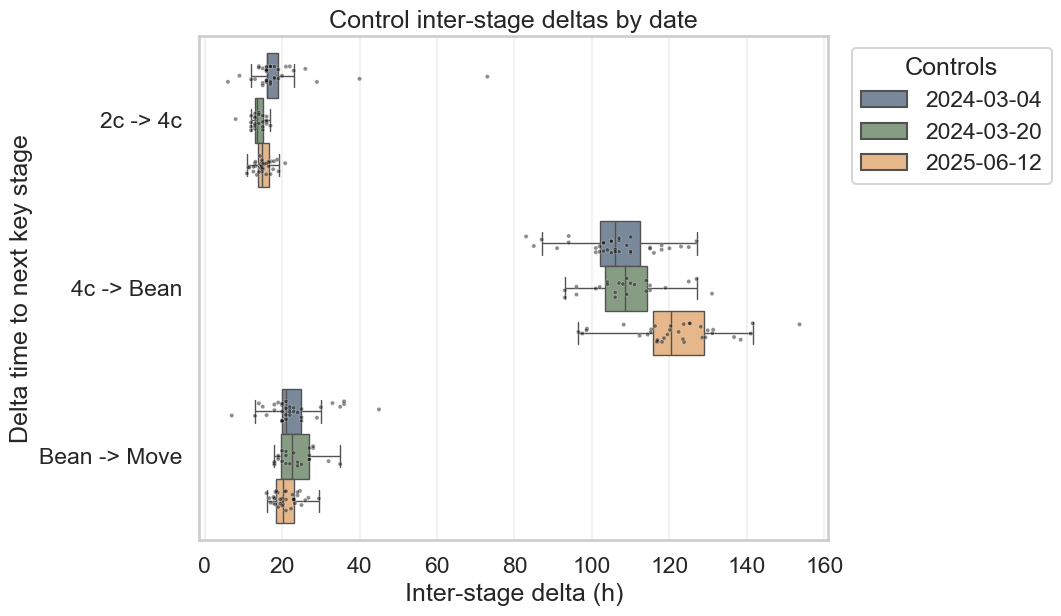

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/plots/boxplot_control_stage_deltas_by_date.png


In [10]:
# Grouped boxplot with strip overlay of control inter-stage deltas by control date

fig_caption_control_deltas_boxplot = (
    "Figure: Grouped boxplot with strip overlay of control inter-stage deltas by control date. "
    "The x-axis is inter-stage time difference in hours (time axis), and the y-axis lists delta groups: "
    "delta_2c_4c (t_4c_h - t_2c_h), delta_4c_bean (t_bean_h - t_4c_h), and delta_bean_move "
    "(t_move_h - t_bean_h). Within each delta group, boxplots are subgrouped by control date "
    "(2024-03-04, 2024-03-20, 2025-06-12). Boxplots summarize median and IQR, while jittered "
    "points show individual egg-level observations. Only control eggs with outcome == l3_reached "
    "are included; subgroup sample sizes can differ because missing stage timestamps propagate to "
    "missing deltas and are excluded."
)
print(fig_caption_control_deltas_boxplot)

delta_plot_df = delta_table[["start_date", *delta_value_cols]].copy()
delta_plot_df["start_date"] = pd.to_datetime(delta_plot_df["start_date"], errors="coerce")
delta_plot_df["date_label"] = delta_plot_df["start_date"].dt.date.astype(str)

delta_plot_long = (
    delta_plot_df.melt(
        id_vars=["date_label"],
        value_vars=delta_value_cols,
        var_name="delta_group",
        value_name="delta_h",
    )
    .dropna(subset=["delta_h"])
    .copy()
)

metric_order = ["delta_2c_4c", "delta_4c_bean", "delta_bean_move"]
date_order = [str(d.date()) for d in CONTROL_DATES]
delta_label_map = {
    "delta_2c_4c": "2c -> 4c",
    "delta_4c_bean": "4c -> Bean",
    "delta_bean_move": "Bean -> Move",
}
metric_label_order = [delta_label_map[m] for m in metric_order]

delta_plot_long["delta_group"] = pd.Categorical(
    delta_plot_long["delta_group"],
    categories=metric_order,
    ordered=True,
)
delta_plot_long["delta_group_label"] = pd.Categorical(
    delta_plot_long["delta_group"].map(delta_label_map),
    categories=metric_label_order,
    ordered=True,
)
delta_plot_long["date_label"] = pd.Categorical(
    delta_plot_long["date_label"],
    categories=date_order,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.boxplot(
    data=delta_plot_long,
    x="delta_h",
    y="delta_group_label",
    hue="date_label",
    order=metric_label_order,
    hue_order=date_order,
    palette=["#75899e", "#83a17f", "#f4b77b"],
    showfliers=False,
    ax=ax,
)

sns.stripplot(
    data=delta_plot_long,
    x="delta_h",
    y="delta_group_label",
    hue="date_label",
    order=metric_label_order,
    hue_order=date_order,
    dodge=True,
    jitter=0.18,
    size=3,
    alpha=0.45,
    linewidth=0.4,
    edgecolor="white",
    palette=["#000000", "#060606", "#000000"],
    ax=ax,
)

ax.set_xlabel("Inter-stage delta (h)")
ax.set_ylabel("Delta time to next key stage")
ax.set_title("Control inter-stage deltas by date")
ax.grid(axis="x", alpha=0.25)

handles, labels = ax.get_legend_handles_labels()
seen = set()
uniq_handles = []
uniq_labels = []
for h, l in zip(handles, labels):
    if l in seen:
        continue
    seen.add(l)
    uniq_handles.append(h)
    uniq_labels.append(l)
ax.legend(uniq_handles, uniq_labels, title="Controls", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
out_png = PLOTS_DIR / "boxplot_control_stage_deltas_by_date.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")



In [11]:
# Significance across control dates within each delta group

from scipy import stats

alpha = 0.05
delta_metrics = ["delta_2c_4c", "delta_4c_bean", "delta_bean_move"]
date_order = CONTROL_DATES.copy()
date_labels = [str(d.date()) for d in date_order]

if "control_stage_deltas_df" not in globals():
    control_stage_deltas_df = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()
    control_stage_deltas_df["delta_2c_4c"] = control_stage_deltas_df["t_4c_h"] - control_stage_deltas_df["t_2c_h"]
    control_stage_deltas_df["delta_4c_bean"] = control_stage_deltas_df["t_bean_h"] - control_stage_deltas_df["t_4c_h"]
    control_stage_deltas_df["delta_bean_move"] = control_stage_deltas_df["t_move_h"] - control_stage_deltas_df["t_bean_h"]

stats_src = control_stage_deltas_df.copy()
stats_src["start_date"] = pd.to_datetime(stats_src["start_date"], errors="coerce")


def p_to_sig(p: float) -> str:
    if np.isnan(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


rows = []
for metric in delta_metrics:
    metric_df = stats_src[["start_date", metric]].dropna(subset=[metric]).copy()
    groups = [metric_df.loc[metric_df["start_date"] == d, metric].to_numpy(dtype=float) for d in date_order]
    sizes = {label: len(arr) for label, arr in zip(date_labels, groups)}

    normality_p = {}
    all_groups_normal = True
    for label, arr in zip(date_labels, groups):
        if len(arr) < 3:
            normality_p[label] = np.nan
            all_groups_normal = False
            continue
        p_norm = float(stats.shapiro(arr).pvalue)
        normality_p[label] = p_norm
        if p_norm < alpha:
            all_groups_normal = False

    if any(len(arr) == 0 for arr in groups):
        test_name = "NA"
        test_stat = np.nan
        p_value = np.nan
    elif all_groups_normal:
        test_name = "ANOVA"
        test_res = stats.f_oneway(*groups)
        test_stat = float(test_res.statistic)
        p_value = float(test_res.pvalue)
    else:
        test_name = "Kruskal-Wallis"
        test_res = stats.kruskal(*groups)
        test_stat = float(test_res.statistic)
        p_value = float(test_res.pvalue)

    rows.append(
        {
            "delta_group": metric,
            "n_2024-03-04": sizes.get("2024-03-04", 0),
            "n_2024-03-20": sizes.get("2024-03-20", 0),
            "n_2025-06-12": sizes.get("2025-06-12", 0),
            "normality_p_2024-03-04": normality_p.get("2024-03-04", np.nan),
            "normality_p_2024-03-20": normality_p.get("2024-03-20", np.nan),
            "normality_p_2025-06-12": normality_p.get("2025-06-12", np.nan),
            "all_groups_normal": bool(all_groups_normal),
            "selected_test": test_name,
            "test_statistic": test_stat,
            "p_value": p_value,
            "significant_0.05": bool(np.isfinite(p_value) and p_value < alpha),
            "sig": p_to_sig(p_value),
        }
    )

control_delta_stats_df = pd.DataFrame(rows)
pd.set_option("display.precision", 4)
display(control_delta_stats_df)

out_csv = TABLES_DIR / "control_delta_omnibus_stats.csv"
control_delta_stats_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,delta_group,n_2024-03-04,n_2024-03-20,n_2025-06-12,normality_p_2024-03-04,normality_p_2024-03-20,normality_p_2025-06-12,all_groups_normal,selected_test,test_statistic,p_value,significant_0.05,sig
0,delta_2c_4c,37,24,36,2.5230e-09,0.0381,0.6223,False,Kruskal-Wallis,21.5060,2.1381e-05,True,***
1,delta_4c_bean,35,24,35,3.7527e-01,0.5410,0.3541,True,ANOVA,17.6345,3.3681e-07,True,***
2,delta_bean_move,35,24,35,1.1573e-02,0.0467,0.1775,False,Kruskal-Wallis,3.7704,1.5180e-01,False,ns


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/control_delta_omnibus_stats.csv


In [12]:
# Post-hoc tests for delta groups with significant omnibus difference

from itertools import combinations
from scipy import stats

alpha = 0.05
date_order = CONTROL_DATES.copy()
date_labels = [str(d.date()) for d in date_order]


def holm_adjust(pvals: np.ndarray) -> np.ndarray:
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        candidate = pvals[idx] * (m - rank)
        running = max(running, candidate)
        adj[idx] = min(running, 1.0)
    return adj


def p_to_sig(p: float) -> str:
    if np.isnan(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def dunn_pairwise(groups: list[np.ndarray]) -> tuple[list[float], list[float]]:
    values = np.concatenate(groups)
    group_ids = np.concatenate([np.full(len(g), i) for i, g in enumerate(groups)])
    ranks = stats.rankdata(values, method="average")

    n_total = len(values)
    _, tie_counts = np.unique(values, return_counts=True)
    if n_total > 1:
        tie_c = 1.0 - float(np.sum(tie_counts ** 3 - tie_counts) / (n_total ** 3 - n_total))
    else:
        tie_c = np.nan

    mean_ranks = [float(np.mean(ranks[group_ids == i])) for i in range(len(groups))]

    z_stats = []
    p_vals = []
    for i, j in combinations(range(len(groups)), 2):
        ni = len(groups[i])
        nj = len(groups[j])
        if ni == 0 or nj == 0 or not np.isfinite(tie_c) or tie_c <= 0:
            z_stats.append(np.nan)
            p_vals.append(np.nan)
            continue

        denom = np.sqrt((n_total * (n_total + 1) / 12.0) * tie_c * (1.0 / ni + 1.0 / nj))
        if denom == 0 or not np.isfinite(denom):
            z_stats.append(np.nan)
            p_vals.append(np.nan)
            continue

        z = (mean_ranks[i] - mean_ranks[j]) / denom
        p = float(2 * stats.norm.sf(abs(z)))
        z_stats.append(float(z))
        p_vals.append(p)

    return z_stats, p_vals


if "control_delta_stats_df" not in globals():
    raise ValueError("Run the previous control-delta significance cell first.")

if "control_stage_deltas_df" not in globals():
    control_stage_deltas_df = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()
    control_stage_deltas_df["delta_2c_4c"] = control_stage_deltas_df["t_4c_h"] - control_stage_deltas_df["t_2c_h"]
    control_stage_deltas_df["delta_4c_bean"] = control_stage_deltas_df["t_bean_h"] - control_stage_deltas_df["t_4c_h"]
    control_stage_deltas_df["delta_bean_move"] = control_stage_deltas_df["t_move_h"] - control_stage_deltas_df["t_bean_h"]

sig_rows = control_delta_stats_df[
    control_delta_stats_df["significant_0.05"]
    & control_delta_stats_df["selected_test"].isin(["ANOVA", "Kruskal-Wallis"])
][["delta_group", "selected_test"]].copy()

posthoc_rows = []
for _, r in sig_rows.iterrows():
    metric = r["delta_group"]
    omnibus_test = r["selected_test"]

    metric_df = control_stage_deltas_df[["start_date", metric]].copy()
    metric_df["start_date"] = pd.to_datetime(metric_df["start_date"], errors="coerce")
    metric_df = metric_df.dropna(subset=[metric])

    groups = [metric_df.loc[metric_df["start_date"] == d, metric].to_numpy(dtype=float) for d in date_order]
    pair_idxs = list(combinations(range(len(date_order)), 2))

    if any(len(g) == 0 for g in groups):
        for i, j in pair_idxs:
            posthoc_rows.append(
                {
                    "delta_group": metric,
                    "omnibus_test": omnibus_test,
                    "posthoc_test": "NA",
                    "comparison": f"{date_labels[i]} vs {date_labels[j]}",
                    "statistic": np.nan,
                    "p_raw": np.nan,
                    "p_adjusted": np.nan,
                    "significant_0.05": False,
                    "sig": "NA",
                }
            )
        continue

    if omnibus_test == "ANOVA":
        try:
            tukey = stats.tukey_hsd(*groups)
            p_mat = np.asarray(tukey.pvalue, dtype=float)
            stat_mat = np.asarray(tukey.statistic, dtype=float)

            for i, j in pair_idxs:
                p_adj = float(p_mat[i, j])
                stat = float(stat_mat[i, j])
                posthoc_rows.append(
                    {
                        "delta_group": metric,
                        "omnibus_test": omnibus_test,
                        "posthoc_test": "Tukey HSD",
                        "comparison": f"{date_labels[i]} vs {date_labels[j]}",
                        "statistic": stat,
                        "p_raw": p_adj,
                        "p_adjusted": p_adj,
                        "significant_0.05": bool(np.isfinite(p_adj) and p_adj < alpha),
                        "sig": p_to_sig(p_adj),
                    }
                )
        except Exception:
            raw_ps = []
            raw_stats = []
            names = []
            for i, j in pair_idxs:
                names.append(f"{date_labels[i]} vs {date_labels[j]}")
                tst = stats.ttest_ind(groups[i], groups[j], equal_var=False, nan_policy="omit")
                raw_stats.append(float(tst.statistic))
                raw_ps.append(float(tst.pvalue))

            raw_ps_arr = np.array(raw_ps, dtype=float)
            adj_ps = holm_adjust(raw_ps_arr)
            for name, stat, p_raw, p_adj in zip(names, raw_stats, raw_ps, adj_ps):
                posthoc_rows.append(
                    {
                        "delta_group": metric,
                        "omnibus_test": omnibus_test,
                        "posthoc_test": "Welch t-test + Holm",
                        "comparison": name,
                        "statistic": stat,
                        "p_raw": p_raw,
                        "p_adjusted": float(p_adj),
                        "significant_0.05": bool(np.isfinite(p_adj) and p_adj < alpha),
                        "sig": p_to_sig(float(p_adj)),
                    }
                )

    elif omnibus_test == "Kruskal-Wallis":
        z_stats, raw_ps = dunn_pairwise(groups)
        raw_ps_arr = np.array(raw_ps, dtype=float)
        valid = np.isfinite(raw_ps_arr)
        adj_ps = np.full_like(raw_ps_arr, np.nan)
        if valid.any():
            adj_ps[valid] = holm_adjust(raw_ps_arr[valid])

        for (i, j), z_stat, p_raw, p_adj in zip(pair_idxs, z_stats, raw_ps, adj_ps):
            posthoc_rows.append(
                {
                    "delta_group": metric,
                    "omnibus_test": omnibus_test,
                    "posthoc_test": "Dunn + Holm",
                    "comparison": f"{date_labels[i]} vs {date_labels[j]}",
                    "statistic": z_stat,
                    "p_raw": p_raw,
                    "p_adjusted": float(p_adj) if np.isfinite(p_adj) else np.nan,
                    "significant_0.05": bool(np.isfinite(p_adj) and p_adj < alpha),
                    "sig": p_to_sig(float(p_adj) if np.isfinite(p_adj) else np.nan),
                }
            )

control_delta_posthoc_df = (
    pd.DataFrame(posthoc_rows)
    .sort_values(["delta_group", "comparison"])
    .reset_index(drop=True)
)

if control_delta_posthoc_df.empty:
    print("No delta groups were significant at omnibus level (alpha=0.05); no post-hoc tests run.")

pd.set_option("display.precision", 4)
display(control_delta_posthoc_df)

out_csv = TABLES_DIR / "control_delta_posthoc_stats.csv"
control_delta_posthoc_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,delta_group,omnibus_test,posthoc_test,comparison,statistic,p_raw,p_adjusted,significant_0.05,sig
0,delta_2c_4c,Kruskal-Wallis,Dunn + Holm,2024-03-04 vs 2024-03-20,4.4948,6.9647e-06,2.0894e-05,True,***
1,delta_2c_4c,Kruskal-Wallis,Dunn + Holm,2024-03-04 vs 2025-06-12,3.0047,2.6584e-03,5.3168e-03,True,**
2,delta_2c_4c,Kruskal-Wallis,Dunn + Holm,2024-03-20 vs 2025-06-12,-1.8011,7.1682e-02,7.1682e-02,False,ns
3,delta_4c_bean,ANOVA,Tukey HSD,2024-03-04 vs 2024-03-20,-2.7583,6.3092e-01,6.3092e-01,False,ns
4,delta_4c_bean,ANOVA,Tukey HSD,2024-03-04 vs 2025-06-12,-15.3286,5.4167e-07,5.4167e-07,True,***
5,delta_4c_bean,ANOVA,Tukey HSD,2024-03-20 vs 2025-06-12,-12.5702,1.9656e-04,1.9656e-04,True,***


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/control_delta_posthoc_stats.csv


In [13]:
# Time differences (hours) for post-hoc significant control-date comparisons

comparison_order = [
    "2024-03-04 vs 2024-03-20",
    "2024-03-04 vs 2025-06-12",
    "2024-03-20 vs 2025-06-12",
]

if "control_delta_posthoc_df" not in globals():
    raise ValueError("Run the post-hoc cell first.")

if "control_stage_deltas_df" not in globals():
    control_stage_deltas_df = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()
    control_stage_deltas_df["delta_2c_4c"] = control_stage_deltas_df["t_4c_h"] - control_stage_deltas_df["t_2c_h"]
    control_stage_deltas_df["delta_4c_bean"] = control_stage_deltas_df["t_bean_h"] - control_stage_deltas_df["t_4c_h"]
    control_stage_deltas_df["delta_bean_move"] = control_stage_deltas_df["t_move_h"] - control_stage_deltas_df["t_bean_h"]

sig_posthoc = control_delta_posthoc_df[control_delta_posthoc_df["significant_0.05"]].copy()
sig_posthoc = sig_posthoc[sig_posthoc["comparison"].isin(comparison_order)].copy()

stats_src = control_stage_deltas_df.copy()
stats_src["start_date"] = pd.to_datetime(stats_src["start_date"], errors="coerce")

rows = []
for _, r in sig_posthoc.iterrows():
    metric = r["delta_group"]
    comparison = r["comparison"]
    date_a_str, date_b_str = comparison.split(" vs ")

    date_a = pd.Timestamp(date_a_str)
    date_b = pd.Timestamp(date_b_str)

    g_a = stats_src.loc[stats_src["start_date"] == date_a, metric].dropna().to_numpy(dtype=float)
    g_b = stats_src.loc[stats_src["start_date"] == date_b, metric].dropna().to_numpy(dtype=float)

    if len(g_a) == 0 or len(g_b) == 0:
        continue

    mean_a = float(np.mean(g_a))
    mean_b = float(np.mean(g_b))
    sd_a = float(np.std(g_a, ddof=1)) if len(g_a) > 1 else np.nan
    sd_b = float(np.std(g_b, ddof=1)) if len(g_b) > 1 else np.nan

    mean_diff = mean_b - mean_a
    sd_diff_indep = np.sqrt(sd_a ** 2 + sd_b ** 2) if np.isfinite(sd_a) and np.isfinite(sd_b) else np.nan

    rows.append(
        {
            "delta_group": metric,
            "comparison": comparison,
            "n_date_a": int(len(g_a)),
            "n_date_b": int(len(g_b)),
            "mean_date_a_h": mean_a,
            "mean_date_b_h": mean_b,
            "mean_diff_h_(b-a)": mean_diff,
            "sd_date_a_h": sd_a,
            "sd_date_b_h": sd_b,
            "sd_diff_indep_h": float(sd_diff_indep) if np.isfinite(sd_diff_indep) else np.nan,
            "p_adjusted": float(r["p_adjusted"]) if np.isfinite(r["p_adjusted"]) else np.nan,
            "sig": r["sig"],
        }
    )

control_delta_sig_diffs_df = pd.DataFrame(rows)

if control_delta_sig_diffs_df.empty:
    print("No post-hoc significant comparisons in the requested date pairs.")
else:
    control_delta_sig_diffs_df["comparison"] = pd.Categorical(
        control_delta_sig_diffs_df["comparison"],
        categories=comparison_order,
        ordered=True,
    )
    control_delta_sig_diffs_df = control_delta_sig_diffs_df.sort_values(
        ["delta_group", "comparison"]
    ).reset_index(drop=True)

pd.set_option("display.precision", 4)
display(control_delta_sig_diffs_df)

out_csv = TABLES_DIR / "control_delta_significant_pair_differences.csv"
control_delta_sig_diffs_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,delta_group,comparison,n_date_a,n_date_b,mean_date_a_h,mean_date_b_h,mean_diff_h_(b-a),sd_date_a_h,sd_date_b_h,sd_diff_indep_h,p_adjusted,sig
0,delta_2c_4c,2024-03-04 vs 2024-03-20,37,24,19.0270,13.7500,-5.2770,10.6731,1.9393,10.8479,2.0894e-05,***
1,delta_2c_4c,2024-03-04 vs 2025-06-12,37,36,19.0270,15.0611,-3.9659,10.6731,2.1908,10.8957,5.3168e-03,**
2,delta_4c_bean,2024-03-04 vs 2025-06-12,35,35,106.2000,121.5286,15.3286,10.6489,12.7610,16.6206,5.4167e-07,***
3,delta_4c_bean,2024-03-20 vs 2025-06-12,24,35,108.9583,121.5286,12.5702,10.0584,12.7610,16.2486,1.9656e-04,***


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/control_delta_significant_pair_differences.csv


Figure: Pooled-control raincloud plot of embryonation-stage timing after combining control eggs from the three control dates (2024-03-04, 2024-03-20, 2025-06-12). The x-axis is elapsed time in hours from incubation start (t_start_h), computed per stage as dt_stage = t_stage_h - t_start_h; the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). The raincloud layers show distribution shape (half-violin), spread and central tendency (box/IQR), and individual observations, with bold labels indicating stage-specific medians. Only control eggs with outcome == l3_reached are included; stage-wise sample size can differ because missing stage timestamps are excluded. Although storage duration at 4°C differed slightly across control dates and produced small timing shifts, controls were pooled because these differences were minor relative to irradiation-associated effects.


/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):
/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


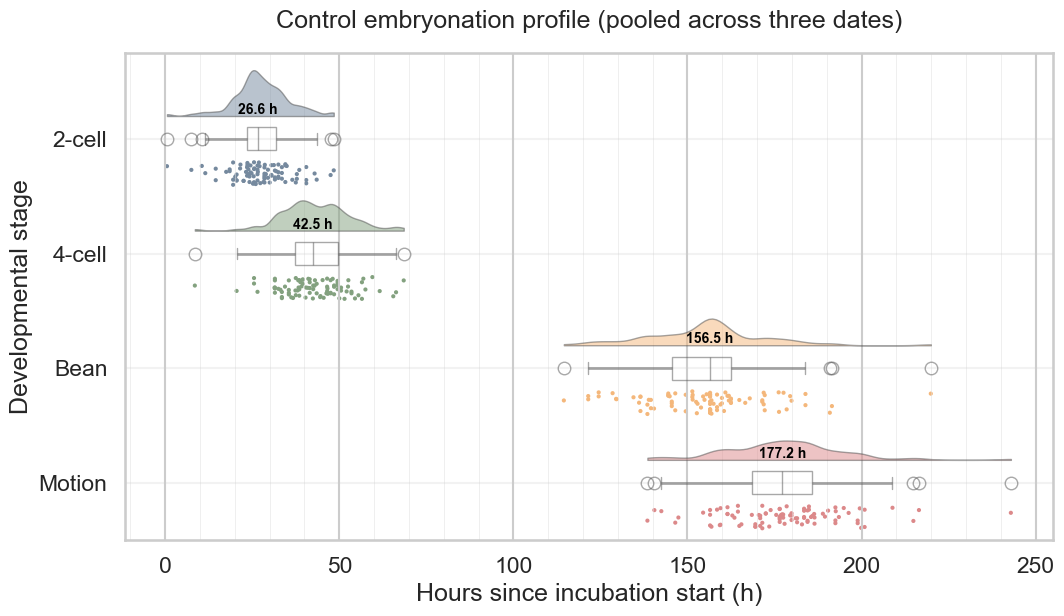

Pooled control eggs (L3 only): 93
Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/plots/raincloud_controls_pooled_three_dates.png


In [14]:
# Plot pooled control stage timing across the combined control dates

fig_caption_pooled_controls = (
    "Figure: Pooled-control raincloud plot of embryonation-stage timing after combining control eggs from "
    "the three control dates (2024-03-04, 2024-03-20, 2025-06-12). The x-axis is elapsed time in hours "
    "from incubation start (t_start_h), computed per stage as dt_stage = t_stage_h - t_start_h; the y-axis "
    "shows developmental stage (2-cell, 4-cell, Bean, Motion). The raincloud layers show distribution "
    "shape (half-violin), spread and central tendency (box/IQR), and individual observations, with bold "
    "labels indicating stage-specific medians. Only control eggs with outcome == l3_reached are included; "
    "stage-wise sample size can differ because missing stage timestamps are excluded. Although storage "
    "duration at 4°C differed slightly across control dates and produced small timing shifts, controls were "
    "pooled because these differences were minor relative to irradiation-associated effects."
)
print(fig_caption_pooled_controls)


try:
    stage_order
except NameError:
    stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}

pooled_ctrl = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()
for s in ["2c", "4c", "bean", "move"]:
    pooled_ctrl[f"dt_{s}"] = pooled_ctrl[f"t_{s}_h"] - pooled_ctrl["t_start_h"]

pooled_ctrl = pooled_ctrl[pooled_ctrl["outcome"] == "l3_reached"].copy()

pooled_plot_df = (
    pooled_ctrl.melt(
        id_vars=["egg_uid", "well_id", "start_date", "outcome"],
        value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
        var_name="stage",
        value_name="dt_h",
    )
    .dropna(subset=["dt_h"])
    .copy()
)
pooled_plot_df["stage"] = pooled_plot_df["stage"].map(stage_label_map)
pooled_plot_df["stage"] = pd.Categorical(pooled_plot_df["stage"], categories=stage_order, ordered=True)

fig, ax = plt.subplots(figsize=(11, 6.5))
pt.RainCloud(
    x="stage",
    y="dt_h",
    data=pooled_plot_df,
    orient="h",
    order=stage_order,
    palette=["#75899e", "#83a17f", "#f4b77b", "#dc898a"],
    bw=0.2,
    width_viol=0.8,
    width_box=0.2,
    move=0.3,
    alpha=0.5,
    dodge=False,
    pointplot=False,
    ax=ax,
)

medians = pooled_plot_df.groupby("stage", observed=True)["dt_h"].median().reindex(stage_order)
label_offset_cat = -0.19
for y, (stage, med) in enumerate(medians.items()):
    ax.text(
        med,
        y + label_offset_cat,
        f"{med:.1f} h",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
        zorder=6,
    )

ax.set(
    xlabel="Hours since incubation start (h)",
    ylabel="Developmental stage",
)
ax.set_title("Control embryonation profile (pooled across three dates)", pad=18)


ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

plt.tight_layout()
out_png = PLOTS_DIR / "raincloud_controls_pooled_three_dates.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

print(f"Pooled control eggs (L3 only): {pooled_ctrl['egg_uid'].nunique()}")
print(f"Saved: {out_png.resolve()}")



In [15]:
# Pooled control stage-delta summary table (all three control dates combined)

delta_metrics = ["delta_2c_4c", "delta_4c_bean", "delta_bean_move"]

if "control_stage_deltas_df" not in globals():
    control_stage_deltas_df = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()
    control_stage_deltas_df["delta_2c_4c"] = control_stage_deltas_df["t_4c_h"] - control_stage_deltas_df["t_2c_h"]
    control_stage_deltas_df["delta_4c_bean"] = control_stage_deltas_df["t_bean_h"] - control_stage_deltas_df["t_4c_h"]
    control_stage_deltas_df["delta_bean_move"] = control_stage_deltas_df["t_move_h"] - control_stage_deltas_df["t_bean_h"]

summary_rows = []
for metric in delta_metrics:
    x = control_stage_deltas_df[metric].dropna().to_numpy(dtype=float)
    if len(x) == 0:
        summary_rows.append(
            {
                "delta_group": metric,
                "n": 0,
                "median_h": np.nan,
                "q1_h": np.nan,
                "q3_h": np.nan,
                "iqr_h": np.nan,
                "median_iqr_h": "NA",
                "mean_h": np.nan,
                "sd_h": np.nan,
                "mean_sd_h": "NA",
            }
        )
        continue

    q1 = float(np.percentile(x, 25))
    median = float(np.percentile(x, 50))
    q3 = float(np.percentile(x, 75))
    iqr = q3 - q1
    mean = float(np.mean(x))
    sd = float(np.std(x, ddof=1)) if len(x) > 1 else np.nan

    summary_rows.append(
        {
            "delta_group": metric,
            "n": int(len(x)),
            "median_h": median,
            "q1_h": q1,
            "q3_h": q3,
            "iqr_h": iqr,
            "median_iqr_h": f"{median:.2f} ({q1:.2f}-{q3:.2f})",
            "mean_h": mean,
            "sd_h": sd,
            "mean_sd_h": f"{mean:.2f} ({sd:.2f})" if np.isfinite(sd) else "NA",
        }
    )

pooled_control_delta_summary_df = pd.DataFrame(summary_rows)

display(pooled_control_delta_summary_df)

out_csv = TABLES_DIR / "control_delta_summary_pooled_three_dates.csv"
pooled_control_delta_summary_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,delta_group,n,median_h,q1_h,q3_h,iqr_h,median_iqr_h,mean_h,sd_h,mean_sd_h
0,delta_2c_4c,97,15.00,13.5,17.00,3.50,15.00 (13.50-17.00),16.2495,7.1017,16.25 (7.10)
1,delta_4c_bean,94,111.65,104.0,120.25,16.25,111.65 (104.00-120.25),112.6117,13.2232,112.61 (13.22)
2,delta_bean_move,94,21.00,19.0,24.45,5.45,21.00 (19.00-24.45),22.3245,5.4739,22.32 (5.47)


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/control_delta_summary_pooled_three_dates.csv


<!-- Cell purpose: Introduce vertical facet rainclouds for cw_30s, pulsed_30s, and pooled controls (3 dates). -->

## Vertical facet rainclouds for cw_30s, pulsed_30s, and pooled controls (3 dates)


Figure: Raincloud comparison of embryonation-stage timing in 30s irradiation groups versus pooled controls. Panels show CW - 30s, Pulsed - 30s, and pooled controls (control dates: 2024-03-04, 2024-03-20, 2025-06-12), with a shared x-axis for direct comparison. The x-axis is elapsed time in hours from t_start_h, computed per stage as dt_stage = t_stage_h - t_start_h; the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). Each raincloud combines distribution shape (half-violin), spread and central tendency (box/IQR), and individual observations, with bold labels indicating stage-specific medians. Only eggs with outcome == l3_reached are included; stage-wise sample sizes can differ because missing stage timestamps are excluded.


/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):
/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default a

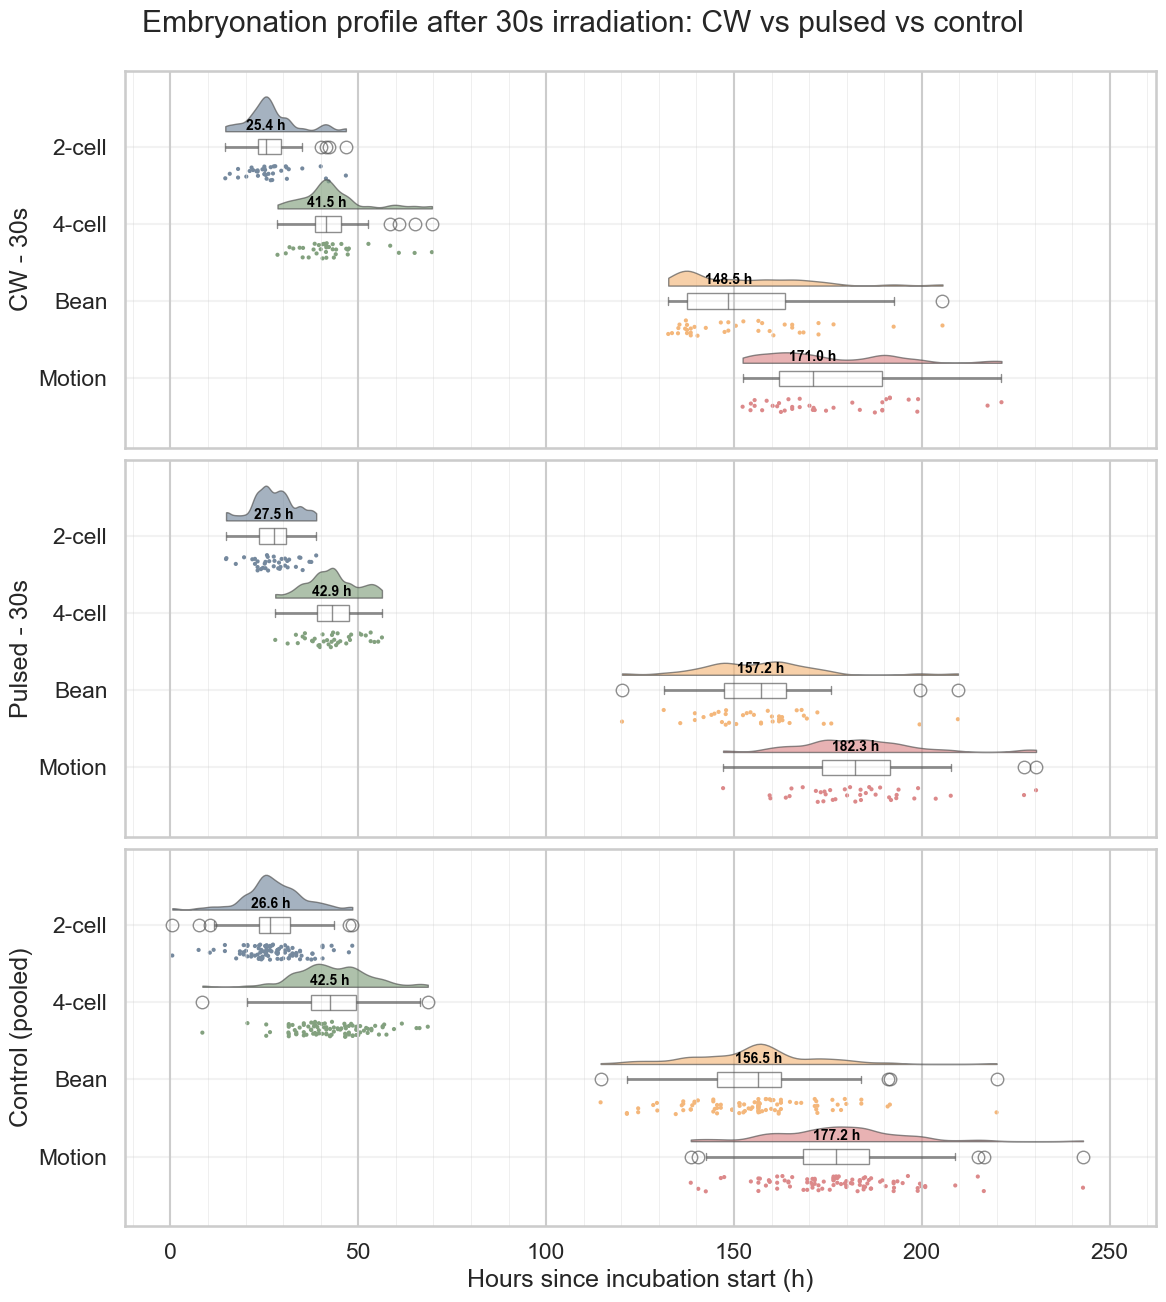

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/plots/raincloud_cw30_pulsed30_control_pooled_3dates.png


In [16]:
# Raincloud comparison of embryonation-stage timing in 30s irradiation groups versus pooled controls

fig_caption_30s = (
    "Figure: Raincloud comparison of embryonation-stage timing in 30s irradiation groups versus "
    "pooled controls. Panels show CW - 30s, Pulsed - 30s, and pooled controls (control dates: "
    "2024-03-04, 2024-03-20, 2025-06-12), with a shared x-axis for direct comparison. The x-axis "
    "is elapsed time in hours from t_start_h, computed per stage as dt_stage = t_stage_h - t_start_h; "
    "the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). Each raincloud combines "
    "distribution shape (half-violin), spread and central tendency (box/IQR), and individual "
    "observations, with bold labels indicating stage-specific medians. Only eggs with outcome == "
    "l3_reached are included; stage-wise sample sizes can differ because missing stage timestamps are "
    "excluded."
)
print(fig_caption_30s)

try:
    stage_order
except NameError:
    stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}

palette_ctrl = ["#75899e", "#83a17f", "#f4b77b", "#dc898a"]
label_offset_cat = -0.18
pad_top_cat = 0.12 * len(stage_order)
pad_bottom_cat = 0.10 * len(stage_order)

exp_s = pd.to_numeric(df["exposure_s"], errors="coerce")

group_specs = [
    (
        "CW - 30s",
        (df["regime"] == "cw") & (exp_s == 30),
    ),
    (
        "Pulsed - 30s",
        (df["regime"] == "pulsed") & (exp_s == 30),
    ),
    (
        "Control (pooled)",
        (df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES)),
    ),
]


def make_plot_df_for_mask(mask: pd.Series) -> pd.DataFrame:
    sub = df[mask].copy()
    if sub.empty:
        return sub
    for s in ["2c", "4c", "bean", "move"]:
        sub[f"dt_{s}"] = sub[f"t_{s}_h"] - sub["t_start_h"]
    sub = sub[sub["outcome"] == "l3_reached"].copy()
    long = (
        sub.melt(
            id_vars=["egg_uid", "well_id", "start_date", "outcome"],
            value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
            var_name="stage",
            value_name="dt_h",
        )
        .dropna(subset=["dt_h"])
        .copy()
    )
    long["stage"] = long["stage"].map(stage_label_map)
    long["stage"] = pd.Categorical(long["stage"], categories=stage_order, ordered=True)
    return long


fig, axes = plt.subplots(len(group_specs), 1, figsize=(12, 14), sharex=True)
if len(group_specs) == 1:
    axes = [axes]

max_dt = 0
for ax, (group_label, mask) in zip(axes, group_specs):
    plot_df = make_plot_df_for_mask(mask)
    if plot_df.empty:
        ax.text(0.5, 0.5, f"No data for {group_label}", ha="center", va="center")
        ax.set_ylabel(group_label)
        continue

    max_dt = max(max_dt, plot_df["dt_h"].max())

    pt.RainCloud(
        x="stage",
        y="dt_h",
        data=plot_df,
        orient="h",
        order=stage_order,
        palette=palette_ctrl,
        bw=0.2,
        width_viol=0.9,
        width_box=0.2,
        move=0.35,
        alpha=0.65,
        dodge=False,
        pointplot=False,
        ax=ax,
    )

    medians = plot_df.groupby("stage", observed=True)["dt_h"].median().reindex(stage_order)
    for y, (stage, med) in enumerate(medians.items()):
        ax.text(
            med,
            y + label_offset_cat,
            f"{med:.1f} h",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="black",
            zorder=6,
        )

    ax.set_ylabel(group_label)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)
    ax.set_ylim(-0.5 - pad_top_cat, len(stage_order) - 0.5 + pad_bottom_cat)
    ax.invert_yaxis()

axes[-1].set_xlabel("Hours since incubation start (h)")
for ax in axes[:-1]:
    ax.set_xlabel("")

for ax in axes:
    pad_left = max(5, 0.05 * max_dt) if max_dt > 0 else 5
    ax.set_xlim(left=-pad_left, right=max_dt * 1.08 if max_dt > 0 else None)

fig.suptitle("Embryonation profile after 30s irradiation: CW vs pulsed vs control", y=0.935)
fig.tight_layout(rect=[0, 0, 1, 0.95], h_pad=0.5)

out_png = PLOTS_DIR / "raincloud_cw30_pulsed30_control_pooled_3dates.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")



Figure: Raincloud comparison of embryonation-stage timing in 60s irradiation groups versus pooled controls. Panels show CW - 60s, Pulsed - 60s, and pooled controls (control dates: 2024-03-04, 2024-03-20, 2025-06-12), with a shared x-axis for direct comparison. The x-axis is elapsed time in hours from t_start_h, computed per stage as dt_stage = t_stage_h - t_start_h; the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). Each raincloud combines distribution shape (half-violin), spread and central tendency (box/IQR), and individual observations, with bold labels indicating stage-specific medians. Only eggs with outcome == l3_reached are included; stage-wise sample sizes can differ because missing stage timestamps are excluded.


/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):
/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default a

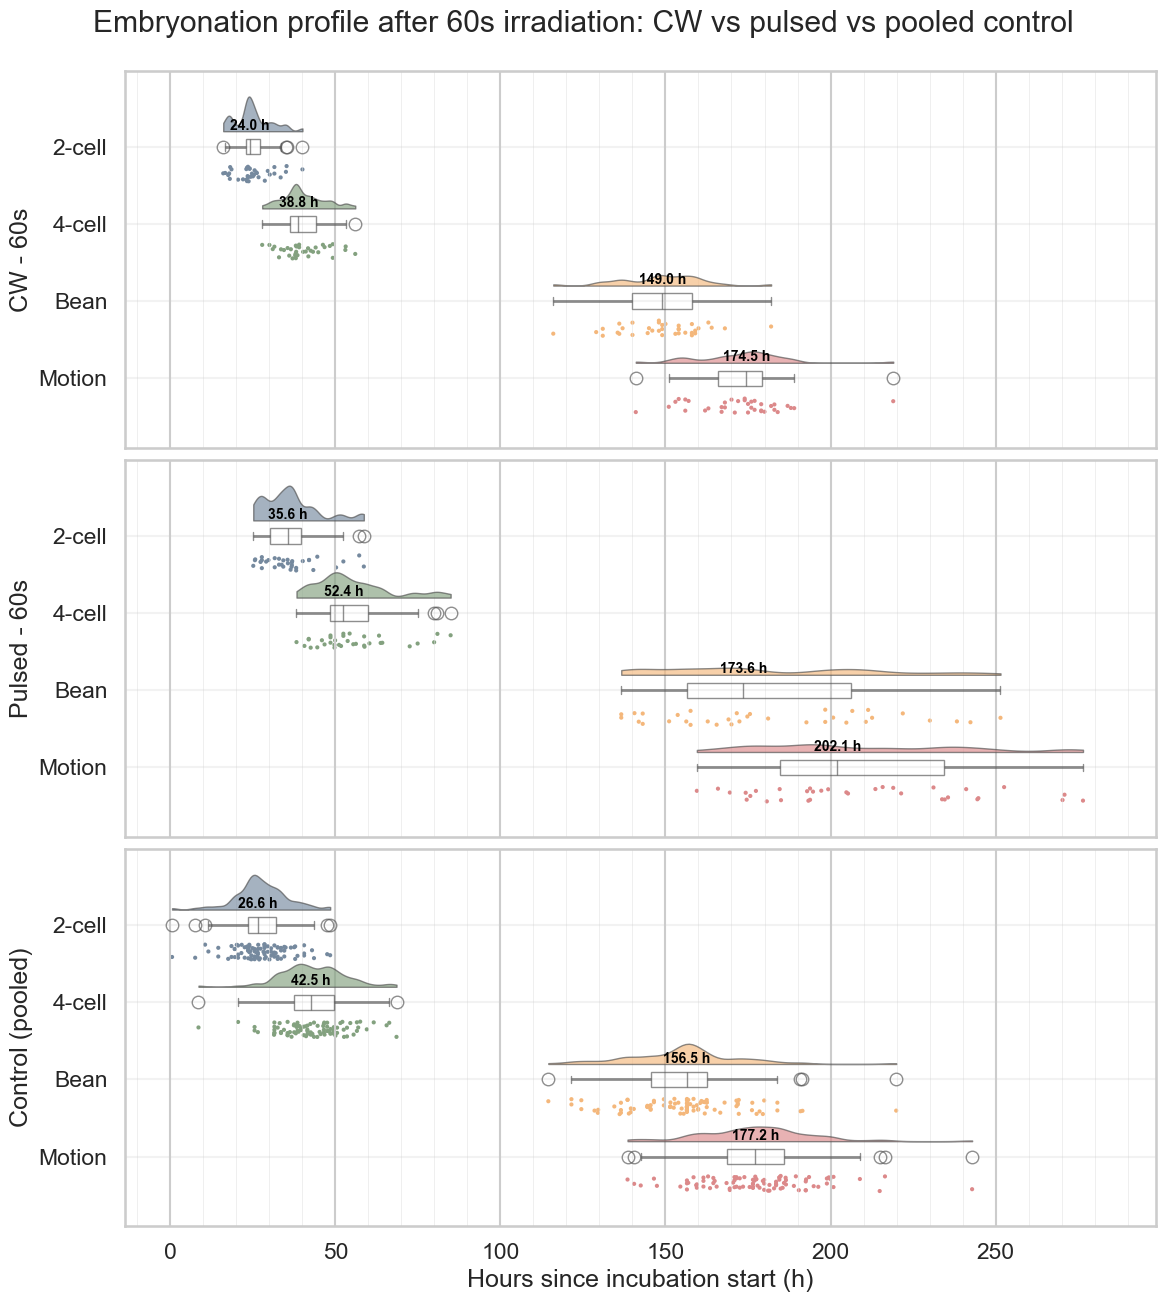

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/plots/raincloud_cw60_pulsed60_control_pooled_3dates.png


In [17]:
# Raincloud comparison of embryonation-stage timing in 60s irradiation groups versus pooled controls

fig_caption_60s = (
    "Figure: Raincloud comparison of embryonation-stage timing in 60s irradiation groups versus "
    "pooled controls. Panels show CW - 60s, Pulsed - 60s, and pooled controls (control dates: "
    "2024-03-04, 2024-03-20, 2025-06-12), with a shared x-axis for direct comparison. The x-axis "
    "is elapsed time in hours from t_start_h, computed per stage as dt_stage = t_stage_h - t_start_h; "
    "the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). Each raincloud combines "
    "distribution shape (half-violin), spread and central tendency (box/IQR), and individual "
    "observations, with bold labels indicating stage-specific medians. Only eggs with outcome == "
    "l3_reached are included; stage-wise sample sizes can differ because missing stage timestamps are "
    "excluded."
)
print(fig_caption_60s)

try:
    stage_order
except NameError:
    stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}

palette_ctrl = ["#75899e", "#83a17f", "#f4b77b", "#dc898a"]
label_offset_cat = -0.18
pad_top_cat = 0.12 * len(stage_order)
pad_bottom_cat = 0.10 * len(stage_order)

exp_s = pd.to_numeric(df["exposure_s"], errors="coerce")

group_specs = [
    (
        "CW - 60s",
        (df["regime"] == "cw") & (exp_s == 60),
    ),
    (
        "Pulsed - 60s",
        (df["regime"] == "pulsed") & (exp_s == 60),
    ),
    (
        "Control (pooled)",
        (df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES)),
    ),
]


def make_plot_df_for_mask(mask: pd.Series) -> pd.DataFrame:
    sub = df[mask].copy()
    if sub.empty:
        return sub
    for s in ["2c", "4c", "bean", "move"]:
        sub[f"dt_{s}"] = sub[f"t_{s}_h"] - sub["t_start_h"]
    sub = sub[sub["outcome"] == "l3_reached"].copy()
    long = (
        sub.melt(
            id_vars=["egg_uid", "well_id", "start_date", "outcome"],
            value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
            var_name="stage",
            value_name="dt_h",
        )
        .dropna(subset=["dt_h"])
        .copy()
    )
    long["stage"] = long["stage"].map(stage_label_map)
    long["stage"] = pd.Categorical(long["stage"], categories=stage_order, ordered=True)
    return long


fig, axes = plt.subplots(len(group_specs), 1, figsize=(12, 14), sharex=True)
if len(group_specs) == 1:
    axes = [axes]

max_dt = 0
for ax, (group_label, mask) in zip(axes, group_specs):
    plot_df = make_plot_df_for_mask(mask)
    if plot_df.empty:
        ax.text(0.5, 0.5, f"No data for {group_label}", ha="center", va="center")
        ax.set_ylabel(group_label)
        continue

    max_dt = max(max_dt, plot_df["dt_h"].max())

    pt.RainCloud(
        x="stage",
        y="dt_h",
        data=plot_df,
        orient="h",
        order=stage_order,
        palette=palette_ctrl,
        bw=0.2,
        width_viol=0.9,
        width_box=0.2,
        move=0.35,
        alpha=0.65,
        dodge=False,
        pointplot=False,
        ax=ax,
    )

    medians = plot_df.groupby("stage", observed=True)["dt_h"].median().reindex(stage_order)
    for y, (stage, med) in enumerate(medians.items()):
        ax.text(
            med,
            y + label_offset_cat,
            f"{med:.1f} h",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="black",
            zorder=6,
        )

    ax.set_ylabel(group_label)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)
    ax.set_ylim(-0.5 - pad_top_cat, len(stage_order) - 0.5 + pad_bottom_cat)
    ax.invert_yaxis()

axes[-1].set_xlabel("Hours since incubation start (h)")
for ax in axes[:-1]:
    ax.set_xlabel("")

for ax in axes:
    pad_left = max(5, 0.05 * max_dt) if max_dt > 0 else 5
    ax.set_xlim(left=-pad_left, right=max_dt * 1.08 if max_dt > 0 else None)

fig.suptitle("Embryonation profile after 60s irradiation: CW vs pulsed vs pooled control", y=0.935)
fig.tight_layout(rect=[0, 0, 1, 0.95], h_pad=0.5)

out_png = PLOTS_DIR / "raincloud_cw60_pulsed60_control_pooled_3dates.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")


Figure: Raincloud comparison of embryonation-stage timing in 120s irradiation groups versus pooled controls. Panels show CW - 120s, Pulsed - 120s, and pooled controls (control dates: 2024-03-04, 2024-03-20, 2025-06-12), with a shared x-axis for direct comparison. The x-axis is elapsed time in hours from t_start_h, computed per stage as dt_stage = t_stage_h - t_start_h; the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). Each raincloud combines distribution shape (half-violin), spread and central tendency (box/IQR), and individual observations, with bold labels indicating stage-specific medians. Only eggs with outcome == l3_reached are included; stage-wise sample sizes can differ because missing stage timestamps are excluded.


/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):
/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default a

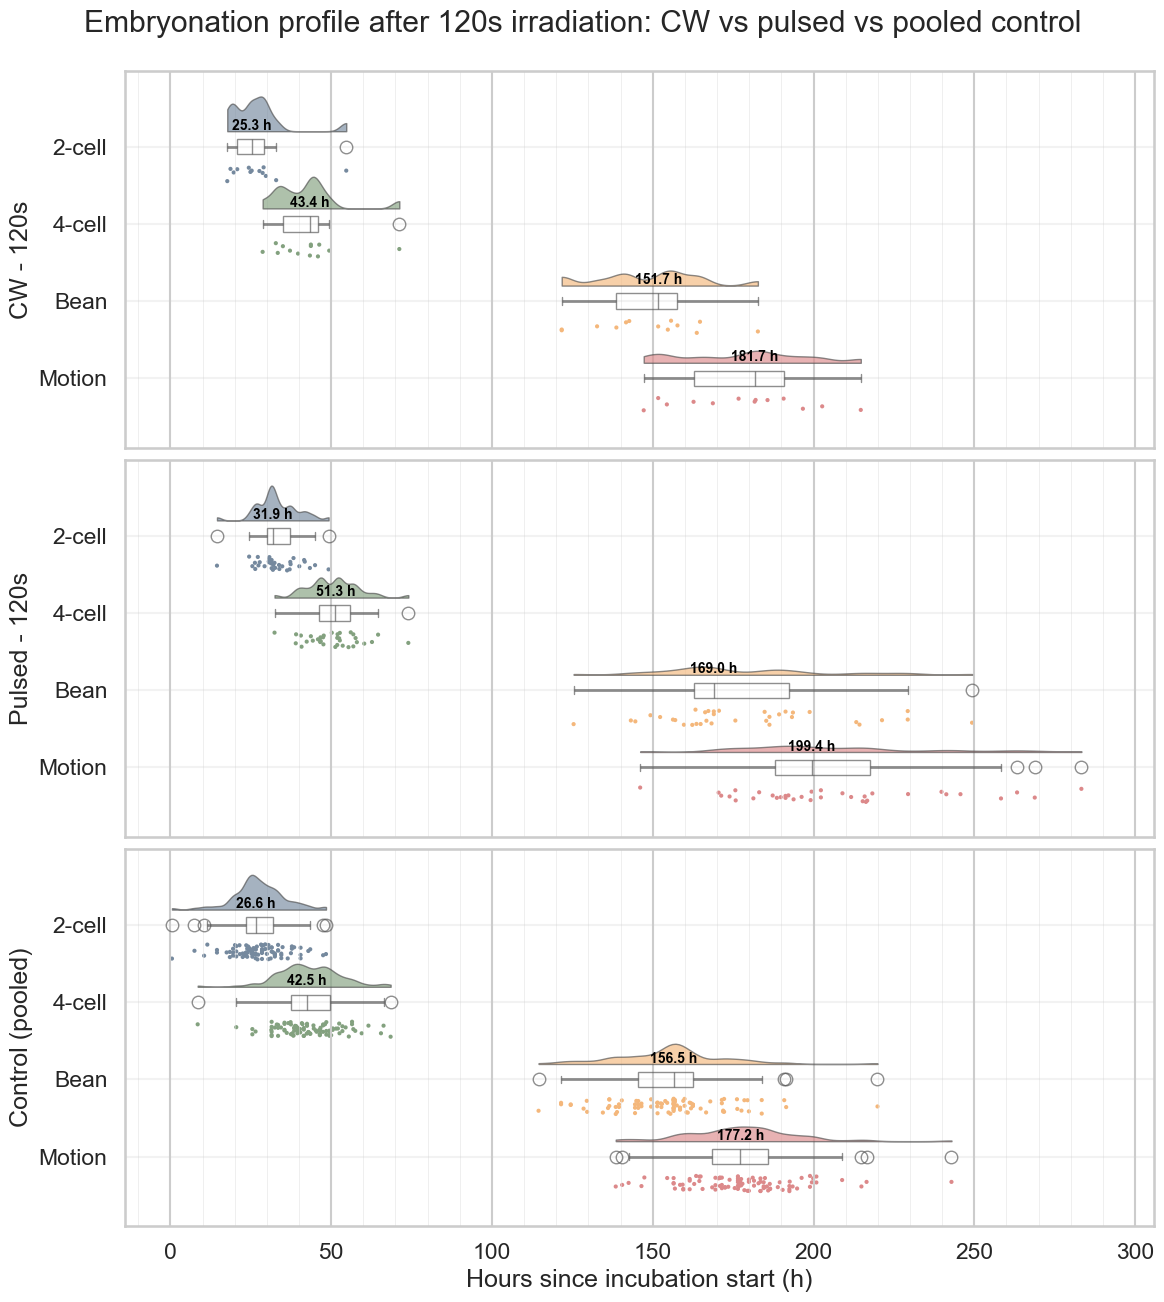

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/plots/raincloud_cw120_pulsed120_control_pooled_3dates.png


In [18]:
# Raincloud comparison of embryonation-stage timing in 120s irradiation groups versus pooled controls

fig_caption_120s = (
    "Figure: Raincloud comparison of embryonation-stage timing in 120s irradiation groups versus "
    "pooled controls. Panels show CW - 120s, Pulsed - 120s, and pooled controls (control dates: "
    "2024-03-04, 2024-03-20, 2025-06-12), with a shared x-axis for direct comparison. The x-axis "
    "is elapsed time in hours from t_start_h, computed per stage as dt_stage = t_stage_h - t_start_h; "
    "the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). Each raincloud combines "
    "distribution shape (half-violin), spread and central tendency (box/IQR), and individual "
    "observations, with bold labels indicating stage-specific medians. Only eggs with outcome == "
    "l3_reached are included; stage-wise sample sizes can differ because missing stage timestamps are "
    "excluded."
)
print(fig_caption_120s)

try:
    stage_order
except NameError:
    stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}

palette_ctrl = ["#75899e", "#83a17f", "#f4b77b", "#dc898a"]
label_offset_cat = -0.18
pad_top_cat = 0.12 * len(stage_order)
pad_bottom_cat = 0.10 * len(stage_order)

exp_s = pd.to_numeric(df["exposure_s"], errors="coerce")

group_specs = [
    (
        "CW - 120s",
        (df["regime"] == "cw") & (exp_s == 120),
    ),
    (
        "Pulsed - 120s",
        (df["regime"] == "pulsed") & (exp_s == 120),
    ),
    (
        "Control (pooled)",
        (df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES)),
    ),
]


def make_plot_df_for_mask(mask: pd.Series) -> pd.DataFrame:
    sub = df[mask].copy()
    if sub.empty:
        return sub
    for s in ["2c", "4c", "bean", "move"]:
        sub[f"dt_{s}"] = sub[f"t_{s}_h"] - sub["t_start_h"]
    sub = sub[sub["outcome"] == "l3_reached"].copy()
    long = (
        sub.melt(
            id_vars=["egg_uid", "well_id", "start_date", "outcome"],
            value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
            var_name="stage",
            value_name="dt_h",
        )
        .dropna(subset=["dt_h"])
        .copy()
    )
    long["stage"] = long["stage"].map(stage_label_map)
    long["stage"] = pd.Categorical(long["stage"], categories=stage_order, ordered=True)
    return long


fig, axes = plt.subplots(len(group_specs), 1, figsize=(12, 14), sharex=True)
if len(group_specs) == 1:
    axes = [axes]

max_dt = 0
for ax, (group_label, mask) in zip(axes, group_specs):
    plot_df = make_plot_df_for_mask(mask)
    if plot_df.empty:
        ax.text(0.5, 0.5, f"No data for {group_label}", ha="center", va="center")
        ax.set_ylabel(group_label)
        continue

    max_dt = max(max_dt, plot_df["dt_h"].max())

    pt.RainCloud(
        x="stage",
        y="dt_h",
        data=plot_df,
        orient="h",
        order=stage_order,
        palette=palette_ctrl,
        bw=0.2,
        width_viol=0.9,
        width_box=0.2,
        move=0.35,
        alpha=0.65,
        dodge=False,
        pointplot=False,
        ax=ax,
    )

    medians = plot_df.groupby("stage", observed=True)["dt_h"].median().reindex(stage_order)
    for y, (stage, med) in enumerate(medians.items()):
        ax.text(
            med,
            y + label_offset_cat,
            f"{med:.1f} h",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="black",
            zorder=6,
        )

    ax.set_ylabel(group_label)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)
    ax.set_ylim(-0.5 - pad_top_cat, len(stage_order) - 0.5 + pad_bottom_cat)
    ax.invert_yaxis()

axes[-1].set_xlabel("Hours since incubation start (h)")
for ax in axes[:-1]:
    ax.set_xlabel("")

for ax in axes:
    pad_left = max(5, 0.05 * max_dt) if max_dt > 0 else 5
    ax.set_xlim(left=-pad_left, right=max_dt * 1.08 if max_dt > 0 else None)

fig.suptitle("Embryonation profile after 120s irradiation: CW vs pulsed vs pooled control", y=0.935)
fig.tight_layout(rect=[0, 0, 1, 0.95], h_pad=0.5)

out_png = PLOTS_DIR / "raincloud_cw120_pulsed120_control_pooled_3dates.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")


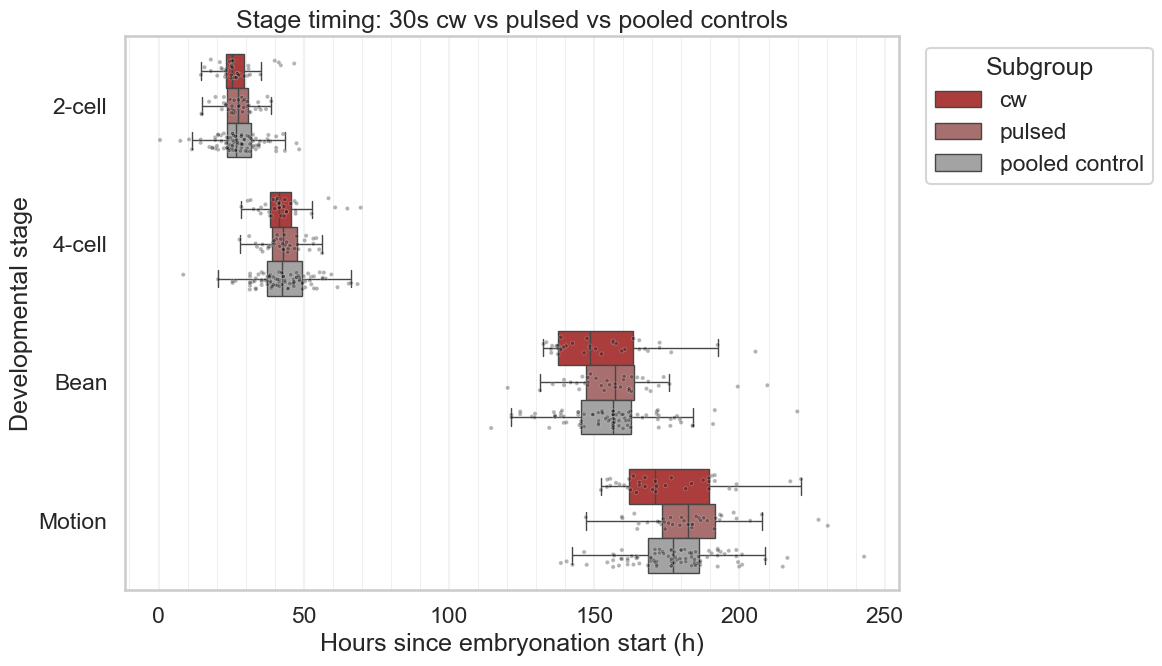

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/plots/boxplot_stages_30s_cw_pulsed_vs_control_pooled.png


In [19]:
# Compare stage timing for the 30s treatments versus pooled controls

try:
    stage_order
except NameError:
    stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}

subgroup_order = ["cw", "pulsed", "pooled control"]
palette = {
    "cw": "#bd2b2b",
    "pulsed": "#b16666",
    "pooled control": "#a3a3a3",
}
point_palette = {
    "cw": "#000000",
    "pulsed": "#000000",
    "pooled control": "#000000",
}

exp_s = pd.to_numeric(df["exposure_s"], errors="coerce")

cw_30 = df[(df["regime"] == "cw") & (exp_s == 30)].copy()
cw_30["subgroup"] = "cw"

pulsed_30 = df[(df["regime"] == "pulsed") & (exp_s == 30)].copy()
pulsed_30["subgroup"] = "pulsed"

ctrl_pooled = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()
ctrl_pooled["subgroup"] = "pooled control"

plot_src = pd.concat([cw_30, pulsed_30, ctrl_pooled], ignore_index=True)
for s in ["2c", "4c", "bean", "move"]:
    plot_src[f"dt_{s}"] = plot_src[f"t_{s}_h"] - plot_src["t_start_h"]

plot_src = plot_src[plot_src["outcome"] == "l3_reached"].copy()

plot_long = (
    plot_src.melt(
        id_vars=["egg_uid", "well_id", "subgroup", "outcome"],
        value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
        var_name="stage",
        value_name="dt_h",
    )
    .dropna(subset=["dt_h"])
    .copy()
)

plot_long["stage"] = plot_long["stage"].map(stage_label_map)
plot_long["stage"] = pd.Categorical(plot_long["stage"], categories=stage_order, ordered=True)
plot_long["subgroup"] = pd.Categorical(plot_long["subgroup"], categories=subgroup_order, ordered=True)

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(
    data=plot_long,
    x="dt_h",
    y="stage",
    hue="subgroup",
    order=stage_order,
    hue_order=subgroup_order,
    palette=palette,
    showfliers=False,
    linewidth=1.0,
    width=0.75,
    ax=ax,
)

sns.stripplot(
    data=plot_long,
    x="dt_h",
    y="stage",
    hue="subgroup",
    order=stage_order,
    hue_order=subgroup_order,
    palette=point_palette,
    dodge=True,
    jitter=0.2,
    size=3,
    alpha=0.3,
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
)

ax.set_ylabel("Developmental stage")
ax.set_xlabel("Hours since embryonation start (h)")
ax.set_title("Stage timing: 30s cw vs pulsed vs pooled controls")
ax.grid(axis="x", alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

handles, labels = ax.get_legend_handles_labels()
seen = set()
uniq_handles = []
uniq_labels = []
for h, l in zip(handles, labels):
    if l in seen:
        continue
    seen.add(l)
    uniq_handles.append(h)
    uniq_labels.append(l)
ax.legend(uniq_handles, uniq_labels, title="Subgroup", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
out_png = PLOTS_DIR / "boxplot_stages_30s_cw_pulsed_vs_control_pooled.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")



Figure: Vertical faceted grouped boxplots of embryonation-stage timing across three irradiation durations (30s, 60s, 120s), comparing CW, Pulsed, and pooled controls. Each facet corresponds to one duration (30s Irradiation, 60s Irradiation, 120s Irradiation) and uses a shared x-axis for direct comparison. The x-axis shows elapsed time in hours from incubation start, calculated per stage as dt_stage = t_stage_h - t_start_h; the y-axis shows stage (2-cell, 4-cell, Bean, Motion). Within each stage, grouped boxplots summarize subgroup distributions (median, IQR, whiskers), and jittered points show individual eggs. CW and Pulsed intentionally share the same fill color, while Pulsed is distinguished by diagonal hatching. Pooled controls combine control dates 2024-03-04, 2024-03-20, and 2025-06-12. Only eggs with outcome == l3_reached are included; stage-wise sample sizes can differ because missing stage timestamps are excluded after long-format reshaping.


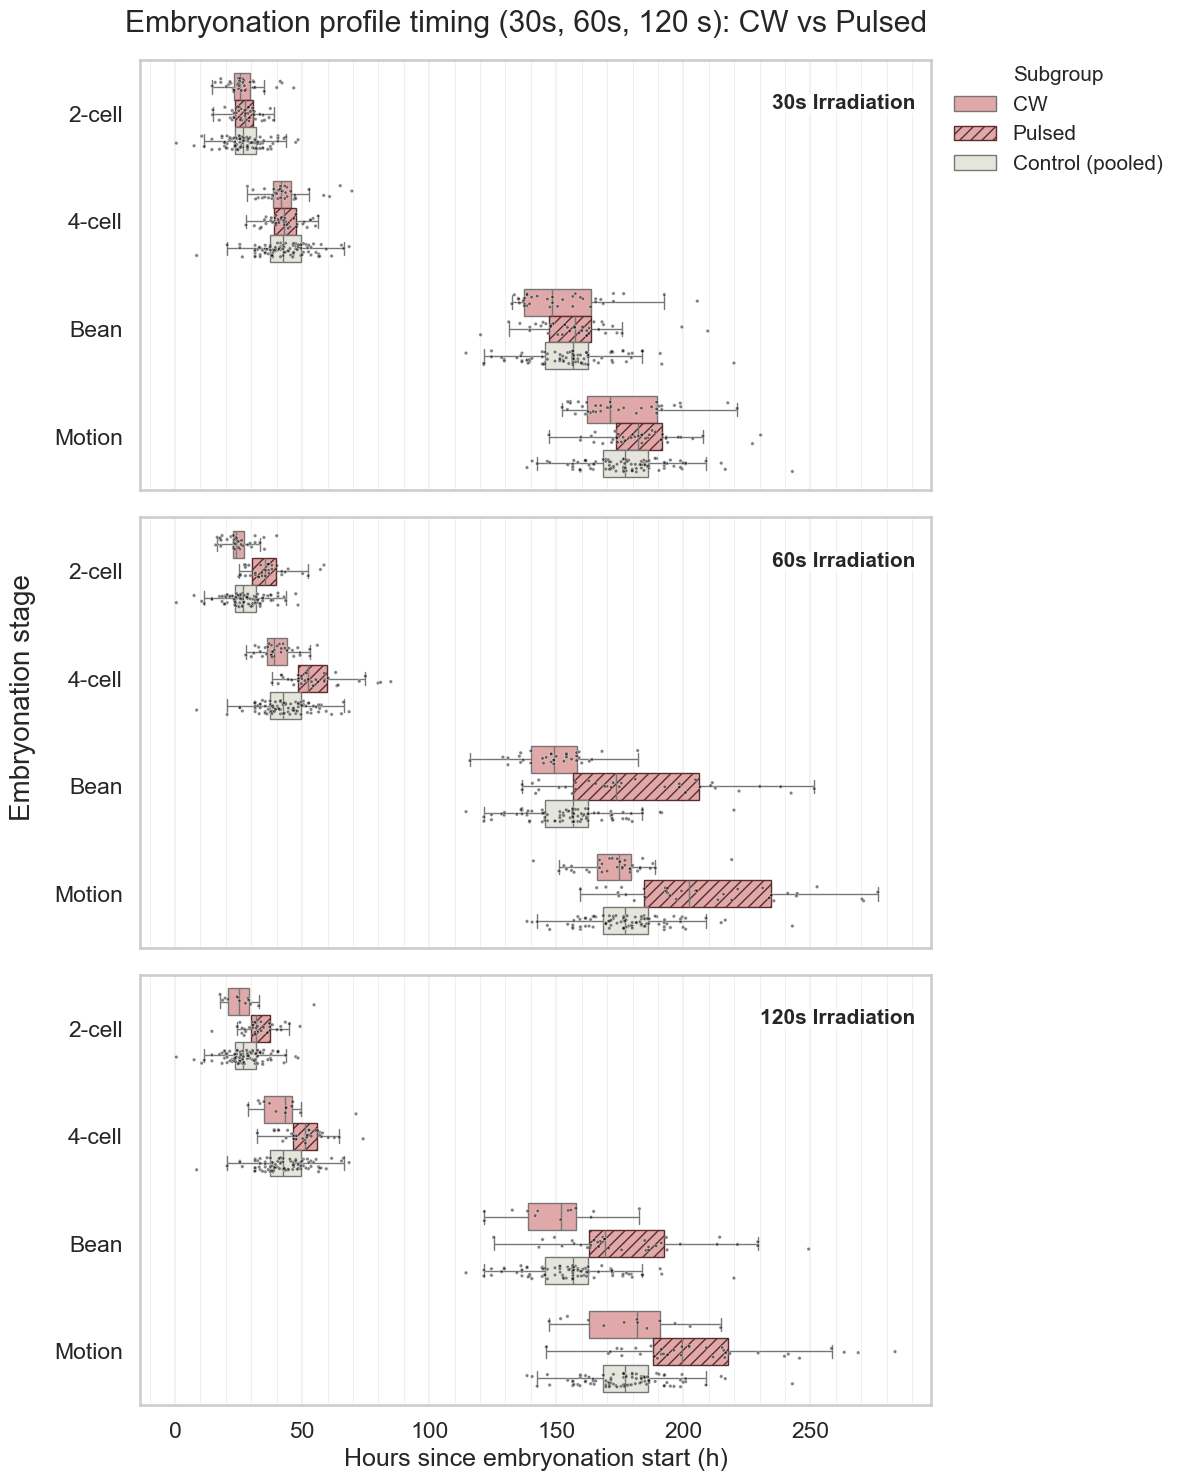

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/plots/boxplot_facets_30s_60s_120s_cw_pulsed_control_pooled.png


In [20]:
# Vertical faceted grouped boxplots of embryonation-stage timing across three irradiation durations (30s, 60s, 120s), comparing CW, Pulsed, and pooled controls

fig_caption_faceted_boxplots_30_60_120 = (
    "Figure: Vertical faceted grouped boxplots of embryonation-stage timing across three irradiation durations "
    "(30s, 60s, 120s), comparing CW, Pulsed, and pooled controls. Each facet corresponds to one duration "
    "(30s Irradiation, 60s Irradiation, 120s Irradiation) and uses a shared x-axis for direct comparison. "
    "The x-axis shows elapsed time in hours from incubation start, calculated per stage as dt_stage = "
    "t_stage_h - t_start_h; the y-axis shows stage (2-cell, 4-cell, Bean, Motion). Within each stage, "
    "grouped boxplots summarize subgroup distributions (median, IQR, whiskers), and jittered points show "
    "individual eggs. CW and Pulsed intentionally share the same fill color, while Pulsed is distinguished "
    "by diagonal hatching. Pooled controls combine control dates 2024-03-04, 2024-03-20, and 2025-06-12. "
    "Only eggs with outcome == l3_reached are included; stage-wise sample sizes can differ because missing "
    "stage timestamps are excluded after long-format reshaping."
)
print(fig_caption_faceted_boxplots_30_60_120)

try:
    stage_order
except NameError:
    stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}

subgroup_order = ["cw", "pulsed", "pooled control"]
facet_order = ["30s", "60s", "120s"]
facet_title_map = {
    "30s": "30s Irradiation",
    "60s": "60s Irradiation",
    "120s": "120s Irradiation",
}
palette = {
    "cw": "#e99f9f",
    "pulsed": "#e99f9f",
    "pooled control": "#e6e6db",
}
point_palette = {
    "cw": "#000000",
    "pulsed": "#000000",
    "pooled control": "#000000",
}

exp_s = pd.to_numeric(df["exposure_s"], errors="coerce")

facet_frames = []
for dur in [30, 60, 120]:
    dur_label = f"{dur}s"

    cw = df[(df["regime"] == "cw") & (exp_s == dur)].copy()
    cw["subgroup"] = "cw"
    cw["duration"] = dur_label

    pulsed = df[(df["regime"] == "pulsed") & (exp_s == dur)].copy()
    pulsed["subgroup"] = "pulsed"
    pulsed["duration"] = dur_label

    ctrl_pooled = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()
    ctrl_pooled["subgroup"] = "pooled control"
    ctrl_pooled["duration"] = dur_label

    sub = pd.concat([cw, pulsed, ctrl_pooled], ignore_index=True)
    for s in ["2c", "4c", "bean", "move"]:
        sub[f"dt_{s}"] = sub[f"t_{s}_h"] - sub["t_start_h"]

    sub = sub[sub["outcome"] == "l3_reached"].copy()
    facet_frames.append(sub)

facet_src = pd.concat(facet_frames, ignore_index=True)

facet_long = (
    facet_src.melt(
        id_vars=["egg_uid", "well_id", "subgroup", "duration", "outcome"],
        value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
        var_name="stage",
        value_name="dt_h",
    )
    .dropna(subset=["dt_h"])
    .copy()
)

facet_long["stage"] = facet_long["stage"].map(stage_label_map)
facet_long["stage"] = pd.Categorical(facet_long["stage"], categories=stage_order, ordered=True)
facet_long["subgroup"] = pd.Categorical(facet_long["subgroup"], categories=subgroup_order, ordered=True)
facet_long["duration"] = pd.Categorical(facet_long["duration"], categories=facet_order, ordered=True)

fig, axes = plt.subplots(len(facet_order), 1, figsize=(12, 16), sharex=True)
if len(facet_order) == 1:
    axes = [axes]

legend_handles = None
legend_labels = None

for ax, dur_label in zip(axes, facet_order):
    sub = facet_long[facet_long["duration"] == dur_label].copy()

    sns.boxplot(
        data=sub,
        x="dt_h",
        y="stage",
        hue="subgroup",
        order=stage_order,
        hue_order=subgroup_order,
        palette=palette,
        showfliers=False,
        linewidth=1.0,
        width=0.75,
        ax=ax,
    )

    n_stage = len(stage_order)
    n_hue = len(subgroup_order)
    pulsed_idx = subgroup_order.index("pulsed")
    expected_boxes = n_stage * n_hue
    box_patches = ax.patches[:expected_boxes]

    start = pulsed_idx * n_stage
    end = min(start + n_stage, len(box_patches))
    for patch in box_patches[start:end]:
        patch.set_hatch("///")
        patch.set_edgecolor("#5a2d2d")
        patch.set_linewidth(1.0)

    sns.stripplot(
        data=sub,
        x="dt_h",
        y="stage",
        hue="subgroup",
        order=stage_order,
        hue_order=subgroup_order,
        palette=point_palette,
        dodge=True,
        jitter=0.2,
        size=2.5,
        alpha=0.5,
        linewidth=0.5,
        edgecolor="white",
        ax=ax,
    )

    ax.text(
        0.98,
        0.92,
        facet_title_map[dur_label],
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=15,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.0",
            "facecolor": "white",
            "edgecolor": "#0C0C0C",
            "linewidth": 0.0,
            "alpha": 0.9,
        },
    )

    ax.set_title("")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

    handles, labels = ax.get_legend_handles_labels()
    if legend_handles is None and legend_labels is None:
        seen = set()
        uniq_h = []
        uniq_l = []
        for h, l in zip(handles, labels):
            if l in seen:
                continue
            seen.add(l)
            uniq_h.append(h)
            uniq_l.append(l)
        legend_handles, legend_labels = uniq_h, uniq_l

    if ax.get_legend() is not None:
        ax.get_legend().remove()

axes[-1].set_xlabel("Hours since embryonation start (h)")
for ax in axes[:-1]:
    ax.set_xlabel("")

if len(facet_long) > 0:
    xmin = float(facet_long["dt_h"].min())
    xmax = float(facet_long["dt_h"].max())
    pad = max(5.0, 0.05 * (xmax - xmin))
    for ax in axes:
        ax.set_xlim(xmin - pad, xmax + pad)

fig.supylabel("Embryonation stage", x=0.07, fontsize=20)

if legend_handles is not None:
    legend_label_map = {
        "cw": "CW",
        "pulsed": "Pulsed",
        "pooled control": "Control (pooled)",
    }
    display_labels = [legend_label_map.get(lbl, lbl) for lbl in legend_labels]

    for h, l in zip(legend_handles, legend_labels):
        if l == "pulsed" and hasattr(h, "set_hatch"):
            h.set_hatch("///")
            h.set_edgecolor("#5a2d2d")
            h.set_linewidth(1.0)

    fig.legend(
        legend_handles,
        display_labels,
        title="Subgroup",
        loc="upper left",
        bbox_to_anchor=(0.85, 0.9),
        frameon=False,
        fontsize=15,
        title_fontsize=15,
        borderaxespad=0.0,
    )

fig.suptitle("Embryonation profile timing (30s, 60s, 120 s): CW vs Pulsed", y=0.93)
plt.tight_layout(rect=[0.04, 0, 0.86, 0.95])
out_png = PLOTS_DIR / "boxplot_facets_30s_60s_120s_cw_pulsed_control_pooled.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")


In [21]:
# Statistical testing per stage for 30s/60s/120s (cw vs pulsed vs pooled control)

from scipy import stats

alpha = 0.05

try:
    stage_order
except NameError:
    stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}

subgroup_order = ["cw", "pulsed", "pooled control"]
facet_order = ["30s", "60s", "120s"]


def p_to_sig(p: float) -> str:
    if np.isnan(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


if "facet_long" not in globals():
    exp_s = pd.to_numeric(df["exposure_s"], errors="coerce")
    facet_frames = []
    for dur in [30, 60, 120]:
        dur_label = f"{dur}s"

        cw = df[(df["regime"] == "cw") & (exp_s == dur)].copy()
        cw["subgroup"] = "cw"
        cw["duration"] = dur_label

        pulsed = df[(df["regime"] == "pulsed") & (exp_s == dur)].copy()
        pulsed["subgroup"] = "pulsed"
        pulsed["duration"] = dur_label

        ctrl_pooled = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()
        ctrl_pooled["subgroup"] = "pooled control"
        ctrl_pooled["duration"] = dur_label

        sub = pd.concat([cw, pulsed, ctrl_pooled], ignore_index=True)
        for s in ["2c", "4c", "bean", "move"]:
            sub[f"dt_{s}"] = sub[f"t_{s}_h"] - sub["t_start_h"]
        sub = sub[sub["outcome"] == "l3_reached"].copy()
        facet_frames.append(sub)

    facet_src = pd.concat(facet_frames, ignore_index=True)
    facet_long = (
        facet_src.melt(
            id_vars=["egg_uid", "well_id", "subgroup", "duration", "outcome"],
            value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
            var_name="stage",
            value_name="dt_h",
        )
        .dropna(subset=["dt_h"])
        .copy()
    )
    facet_long["stage"] = facet_long["stage"].map(stage_label_map)
    facet_long["stage"] = pd.Categorical(facet_long["stage"], categories=stage_order, ordered=True)
    facet_long["subgroup"] = pd.Categorical(facet_long["subgroup"], categories=subgroup_order, ordered=True)
    facet_long["duration"] = pd.Categorical(facet_long["duration"], categories=facet_order, ordered=True)

rows = []
for duration in facet_order:
    for stage in stage_order:
        sub = facet_long[(facet_long["duration"] == duration) & (facet_long["stage"] == stage)].copy()

        groups = [
            sub.loc[sub["subgroup"] == subgroup, "dt_h"].to_numpy(dtype=float)
            for subgroup in subgroup_order
        ]
        sizes = {g: len(arr) for g, arr in zip(subgroup_order, groups)}

        normality_p = {}
        all_groups_normal = True
        for g, arr in zip(subgroup_order, groups):
            if len(arr) < 3:
                normality_p[g] = np.nan
                all_groups_normal = False
                continue
            p_norm = float(stats.shapiro(arr).pvalue)
            normality_p[g] = p_norm
            if p_norm < alpha:
                all_groups_normal = False

        if any(len(arr) == 0 for arr in groups):
            test_name = "NA"
            test_stat = np.nan
            p_value = np.nan
        elif all_groups_normal:
            test_name = "ANOVA"
            tst = stats.f_oneway(*groups)
            test_stat = float(tst.statistic)
            p_value = float(tst.pvalue)
        else:
            test_name = "Kruskal-Wallis"
            tst = stats.kruskal(*groups)
            test_stat = float(tst.statistic)
            p_value = float(tst.pvalue)

        rows.append(
            {
                "duration": duration,
                "stage": stage,
                "n_cw": sizes.get("cw", 0),
                "n_pulsed": sizes.get("pulsed", 0),
                "n_pooled_control": sizes.get("pooled control", 0),
                "normality_p_cw": normality_p.get("cw", np.nan),
                "normality_p_pulsed": normality_p.get("pulsed", np.nan),
                "normality_p_pooled_control": normality_p.get("pooled control", np.nan),
                "all_groups_normal": bool(all_groups_normal),
                "selected_test": test_name,
                "test_statistic": test_stat,
                "p_value": p_value,
                "significant_0.05": bool(np.isfinite(p_value) and p_value < alpha),
                "sig": p_to_sig(p_value),
            }
        )

stats_duration_stage_df = pd.DataFrame(rows)
stats_duration_stage_df["duration"] = pd.Categorical(
    stats_duration_stage_df["duration"],
    categories=facet_order,
    ordered=True,
)
stats_duration_stage_df["stage"] = pd.Categorical(
    stats_duration_stage_df["stage"],
    categories=stage_order,
    ordered=True,
)
stats_duration_stage_df = stats_duration_stage_df.sort_values(["duration", "stage"]).reset_index(drop=True)

pd.set_option("display.precision", 4)
display(stats_duration_stage_df)

out_csv = TABLES_DIR / "treatment_duration_stage_omnibus_stats.csv"
stats_duration_stage_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,duration,stage,n_cw,n_pulsed,n_pooled_control,normality_p_cw,normality_p_pulsed,normality_p_pooled_control,all_groups_normal,selected_test,test_statistic,p_value,significant_0.05,sig
0,30s,2-cell,37,39,93,0.0096,0.7775,0.0891,False,Kruskal-Wallis,1.0816,5.8229e-01,False,ns
1,30s,4-cell,37,39,93,0.0018,0.8238,0.3259,False,Kruskal-Wallis,0.2908,8.6467e-01,False,ns
2,30s,Bean,37,39,93,0.0011,0.0377,0.0178,False,Kruskal-Wallis,2.8215,2.4396e-01,False,ns
3,30s,Motion,37,39,93,0.0108,0.1062,0.0462,False,Kruskal-Wallis,5.0192,8.1299e-02,False,ns
4,60s,2-cell,36,34,93,0.0835,0.0097,0.0891,False,Kruskal-Wallis,38.2477,4.9502e-09,True,***
5,60s,4-cell,36,34,93,0.4778,0.0131,0.3259,False,Kruskal-Wallis,36.7027,1.0718e-08,True,***
6,60s,Bean,36,34,93,0.6758,0.0867,0.0178,False,Kruskal-Wallis,24.9214,3.8761e-06,True,***
7,60s,Motion,36,34,93,0.0560,0.1256,0.0462,False,Kruskal-Wallis,35.4935,1.9620e-08,True,***
8,120s,2-cell,13,35,93,0.0040,0.3589,0.0891,False,Kruskal-Wallis,17.4453,1.6285e-04,True,***
9,120s,4-cell,13,35,93,0.0382,0.7666,0.3259,False,Kruskal-Wallis,18.2692,1.0787e-04,True,***


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/treatment_duration_stage_omnibus_stats.csv


In [22]:
# Dunn post-hoc for significant duration-stage groups (cw/pulsed vs pooled control only)

from scipy import stats

alpha = 0.05
subgroup_order = ["cw", "pulsed", "pooled control"]
contrast_pairs = [
    ("cw", "pooled control"),
    ("pulsed", "pooled control"),
]


def holm_adjust(pvals: np.ndarray) -> np.ndarray:
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        candidate = pvals[idx] * (m - rank)
        running = max(running, candidate)
        adj[idx] = min(running, 1.0)
    return adj


def p_to_sig(p: float) -> str:
    if np.isnan(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def dunn_pair_contrast(groups: dict[str, np.ndarray], g1: str, g2: str) -> tuple[float, float]:
    arrays = [groups[g] for g in subgroup_order]
    values = np.concatenate(arrays)
    n_total = len(values)

    if n_total < 2 or len(groups[g1]) == 0 or len(groups[g2]) == 0:
        return np.nan, np.nan

    group_ids = np.concatenate([np.full(len(groups[g]), i) for i, g in enumerate(subgroup_order)])
    ranks = stats.rankdata(values, method="average")

    _, tie_counts = np.unique(values, return_counts=True)
    tie_c = 1.0 - float(np.sum(tie_counts ** 3 - tie_counts) / (n_total ** 3 - n_total))
    if tie_c <= 0 or not np.isfinite(tie_c):
        return np.nan, np.nan

    mean_ranks = {}
    for i, g in enumerate(subgroup_order):
        arr = groups[g]
        if len(arr) == 0:
            mean_ranks[g] = np.nan
        else:
            mean_ranks[g] = float(np.mean(ranks[group_ids == i]))

    n1 = len(groups[g1])
    n2 = len(groups[g2])
    denom = np.sqrt((n_total * (n_total + 1) / 12.0) * tie_c * (1.0 / n1 + 1.0 / n2))
    if denom == 0 or not np.isfinite(denom):
        return np.nan, np.nan

    z = (mean_ranks[g1] - mean_ranks[g2]) / denom
    p = float(2 * stats.norm.sf(abs(z)))
    return float(z), p


if "stats_duration_stage_df" not in globals():
    raise ValueError("Run the previous omnibus statistics cell first.")
if "facet_long" not in globals():
    raise ValueError("Run the facet plotting/statistics cells first so facet_long is available.")

sig_targets = stats_duration_stage_df[stats_duration_stage_df["significant_0.05"]].copy()

rows = []
for _, t in sig_targets.iterrows():
    duration = t["duration"]
    stage = t["stage"]
    omnibus_test = t["selected_test"]

    sub = facet_long[(facet_long["duration"] == duration) & (facet_long["stage"] == stage)].copy()
    groups = {
        g: sub.loc[sub["subgroup"] == g, "dt_h"].to_numpy(dtype=float)
        for g in subgroup_order
    }

    raw_ps = []
    raw_zs = []
    comp_names = []
    ns = []

    for g1, g2 in contrast_pairs:
        z, p_raw = dunn_pair_contrast(groups, g1, g2)
        raw_zs.append(z)
        raw_ps.append(p_raw)
        comp_names.append(f"{g1} vs {g2}")
        ns.append((len(groups[g1]), len(groups[g2])))

    raw_ps_arr = np.array(raw_ps, dtype=float)
    valid = np.isfinite(raw_ps_arr)
    p_adj = np.full_like(raw_ps_arr, np.nan)
    if valid.any():
        p_adj[valid] = holm_adjust(raw_ps_arr[valid])

    for comp, (n1, n2), z, p_raw, p_holm in zip(comp_names, ns, raw_zs, raw_ps, p_adj):
        rows.append(
            {
                "duration": duration,
                "stage": stage,
                "omnibus_test": omnibus_test,
                "comparison": comp,
                "n_group1": int(n1),
                "n_group2": int(n2),
                "dunn_z": z,
                "p_raw": p_raw,
                "p_holm": float(p_holm) if np.isfinite(p_holm) else np.nan,
                "significant_0.05": bool(np.isfinite(p_holm) and p_holm < alpha),
                "sig": p_to_sig(float(p_holm) if np.isfinite(p_holm) else np.nan),
            }
        )

stats_duration_stage_dunn_df = pd.DataFrame(rows)
if not stats_duration_stage_dunn_df.empty:
    stats_duration_stage_dunn_df["duration"] = pd.Categorical(
        stats_duration_stage_dunn_df["duration"],
        categories=["30s", "60s", "120s"],
        ordered=True,
    )
    stats_duration_stage_dunn_df["stage"] = pd.Categorical(
        stats_duration_stage_dunn_df["stage"],
        categories=["2-cell", "4-cell", "Bean", "Motion"],
        ordered=True,
    )
    stats_duration_stage_dunn_df = stats_duration_stage_dunn_df.sort_values(
        ["duration", "stage", "comparison"]
    ).reset_index(drop=True)
else:
    print("No significant omnibus duration-stage groups found; no Dunn post-hoc rows generated.")

pd.set_option("display.precision", 4)
display(stats_duration_stage_dunn_df)

out_csv = TABLES_DIR / "treatment_duration_stage_dunn_vs_control.csv"
stats_duration_stage_dunn_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,duration,stage,omnibus_test,comparison,n_group1,n_group2,dunn_z,p_raw,p_holm,significant_0.05,sig
0,60s,2-cell,Kruskal-Wallis,cw vs pooled control,36,93,-2.1940,2.8237e-02,2.8237e-02,True,*
1,60s,2-cell,Kruskal-Wallis,pulsed vs pooled control,34,93,4.9623,6.9647e-07,1.3929e-06,True,***
2,60s,4-cell,Kruskal-Wallis,cw vs pooled control,36,93,-1.7138,8.6573e-02,8.6573e-02,False,ns
3,60s,4-cell,Kruskal-Wallis,pulsed vs pooled control,34,93,5.1211,3.0373e-07,6.0746e-07,True,***
4,60s,Bean,Kruskal-Wallis,cw vs pooled control,36,93,-1.9473,5.1503e-02,5.1503e-02,False,ns
5,60s,Bean,Kruskal-Wallis,pulsed vs pooled control,34,93,3.8894,1.0050e-04,2.0099e-04,True,***
6,60s,Motion,Kruskal-Wallis,cw vs pooled control,36,93,-1.5988,1.0986e-01,1.0986e-01,False,ns
7,60s,Motion,Kruskal-Wallis,pulsed vs pooled control,34,93,5.0835,3.7048e-07,7.4096e-07,True,***
8,120s,2-cell,Kruskal-Wallis,cw vs pooled control,13,93,-0.6750,4.9969e-01,4.9969e-01,False,ns
9,120s,2-cell,Kruskal-Wallis,pulsed vs pooled control,35,93,3.9286,8.5458e-05,1.7092e-04,True,***


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/treatment_duration_stage_dunn_vs_control.csv


In [23]:
# Dunn post-hoc: 60s pulsed vs 120s pulsed for each stage

from scipy import stats

alpha = 0.05

try:
    stage_order
except NameError:
    stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}


def holm_adjust(pvals: np.ndarray) -> np.ndarray:
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        candidate = pvals[idx] * (m - rank)
        running = max(running, candidate)
        adj[idx] = min(running, 1.0)
    return adj


def p_to_sig(p: float) -> str:
    if np.isnan(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def dunn_two_group(g1: np.ndarray, g2: np.ndarray) -> tuple[float, float]:
    if len(g1) == 0 or len(g2) == 0:
        return np.nan, np.nan

    values = np.concatenate([g1, g2])
    n_total = len(values)
    if n_total < 2:
        return np.nan, np.nan

    ranks = stats.rankdata(values, method="average")
    r1 = ranks[:len(g1)]
    r2 = ranks[len(g1):]

    _, tie_counts = np.unique(values, return_counts=True)
    tie_c = 1.0 - float(np.sum(tie_counts ** 3 - tie_counts) / (n_total ** 3 - n_total))
    if tie_c <= 0 or not np.isfinite(tie_c):
        return np.nan, np.nan

    mean_r1 = float(np.mean(r1))
    mean_r2 = float(np.mean(r2))

    denom = np.sqrt((n_total * (n_total + 1) / 12.0) * tie_c * (1.0 / len(g1) + 1.0 / len(g2)))
    if denom == 0 or not np.isfinite(denom):
        return np.nan, np.nan

    z = (mean_r1 - mean_r2) / denom
    p = float(2 * stats.norm.sf(abs(z)))
    return float(z), p


if "facet_long" not in globals():
    exp_s = pd.to_numeric(df["exposure_s"], errors="coerce")
    facet_frames = []
    for dur in [30, 60, 120]:
        dur_label = f"{dur}s"

        cw = df[(df["regime"] == "cw") & (exp_s == dur)].copy()
        cw["subgroup"] = "cw"
        cw["duration"] = dur_label

        pulsed = df[(df["regime"] == "pulsed") & (exp_s == dur)].copy()
        pulsed["subgroup"] = "pulsed"
        pulsed["duration"] = dur_label

        ctrl_pooled = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()
        ctrl_pooled["subgroup"] = "pooled control"
        ctrl_pooled["duration"] = dur_label

        sub = pd.concat([cw, pulsed, ctrl_pooled], ignore_index=True)
        for s in ["2c", "4c", "bean", "move"]:
            sub[f"dt_{s}"] = sub[f"t_{s}_h"] - sub["t_start_h"]
        sub = sub[sub["outcome"] == "l3_reached"].copy()
        facet_frames.append(sub)

    facet_src = pd.concat(facet_frames, ignore_index=True)
    facet_long = (
        facet_src.melt(
            id_vars=["egg_uid", "well_id", "subgroup", "duration", "outcome"],
            value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
            var_name="stage",
            value_name="dt_h",
        )
        .dropna(subset=["dt_h"])
        .copy()
    )
    facet_long["stage"] = facet_long["stage"].map(stage_label_map)

rows = []
for stage in stage_order:
    g60 = facet_long[
        (facet_long["duration"] == "60s")
        & (facet_long["subgroup"] == "pulsed")
        & (facet_long["stage"] == stage)
    ]["dt_h"].to_numpy(dtype=float)

    g120 = facet_long[
        (facet_long["duration"] == "120s")
        & (facet_long["subgroup"] == "pulsed")
        & (facet_long["stage"] == stage)
    ]["dt_h"].to_numpy(dtype=float)

    z, p_raw = dunn_two_group(g60, g120)
    rows.append(
        {
            "stage": stage,
            "comparison": "60s pulsed vs 120s pulsed",
            "n_60s_pulsed": int(len(g60)),
            "n_120s_pulsed": int(len(g120)),
            "dunn_z": z,
            "p_raw": p_raw,
        }
    )

stats_pulsed_60_vs_120_dunn_df = pd.DataFrame(rows)

raw_ps = stats_pulsed_60_vs_120_dunn_df["p_raw"].to_numpy(dtype=float)
valid = np.isfinite(raw_ps)
p_holm = np.full_like(raw_ps, np.nan)
if valid.any():
    p_holm[valid] = holm_adjust(raw_ps[valid])

stats_pulsed_60_vs_120_dunn_df["p_holm"] = p_holm
stats_pulsed_60_vs_120_dunn_df["significant_0.05"] = stats_pulsed_60_vs_120_dunn_df["p_holm"].map(
    lambda p: bool(np.isfinite(p) and p < alpha)
)
stats_pulsed_60_vs_120_dunn_df["sig"] = stats_pulsed_60_vs_120_dunn_df["p_holm"].map(p_to_sig)
stats_pulsed_60_vs_120_dunn_df["stage"] = pd.Categorical(
    stats_pulsed_60_vs_120_dunn_df["stage"],
    categories=stage_order,
    ordered=True,
)
stats_pulsed_60_vs_120_dunn_df = stats_pulsed_60_vs_120_dunn_df.sort_values("stage").reset_index(drop=True)

pd.set_option("display.precision", 4)
display(stats_pulsed_60_vs_120_dunn_df)

out_csv = TABLES_DIR / "pulsed_60_vs_120_dunn_by_stage.csv"
stats_pulsed_60_vs_120_dunn_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,stage,comparison,n_60s_pulsed,n_120s_pulsed,dunn_z,p_raw,p_holm,significant_0.05,sig
0,2-cell,60s pulsed vs 120s pulsed,34,35,1.5365,0.1244,0.4975,False,ns
1,4-cell,60s pulsed vs 120s pulsed,34,35,1.5366,0.1244,0.4975,False,ns
2,Bean,60s pulsed vs 120s pulsed,34,35,0.2101,0.8336,1.0000,False,ns
3,Motion,60s pulsed vs 120s pulsed,34,35,0.3181,0.7504,1.0000,False,ns


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/pulsed_60_vs_120_dunn_by_stage.csv


Figure: Grouped boxplot with strip overlay comparing pooled control versus pulsed irradiation (60s and 120s) across embryonation stages. The x-axis shows elapsed time in hours from incubation start, calculated per stage as dt_stage = t_stage_h - t_start_h; the y-axis shows stage (2-cell, 4-cell, Bean, Motion). Boxplots summarize subgroup distributions (median, IQR, whiskers), and jittered points show individual eggs. Pooled controls combine control dates 2024-03-04, 2024-03-20, and 2025-06-12. Only eggs with outcome == l3_reached are included; stage-wise sample sizes can differ because missing stage timestamps are excluded after long-format reshaping.


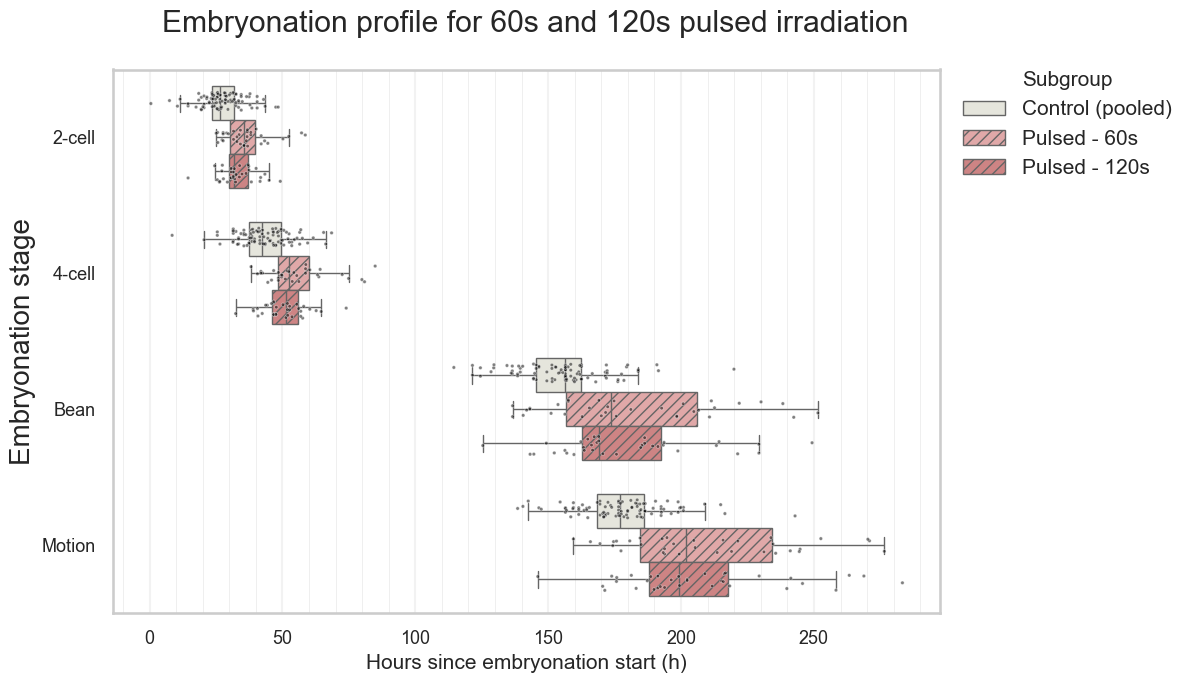

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/plots/boxplot_stages_pulsed60_pulsed120_vs_control_pooled.png


In [24]:
# Compare pooled controls with pulsed 60s and 120s stage timings

fig_caption_pulsed_60_120_vs_control = (
    "Figure: Grouped boxplot with strip overlay comparing pooled control versus pulsed irradiation "
    "(60s and 120s) across embryonation stages. The x-axis shows elapsed time in hours from incubation "
    "start, calculated per stage as dt_stage = t_stage_h - t_start_h; the y-axis shows stage (2-cell, "
    "4-cell, Bean, Motion). Boxplots summarize subgroup distributions (median, IQR, whiskers), and "
    "jittered points show individual eggs. Pooled controls combine control dates 2024-03-04, 2024-03-20, "
    "and 2025-06-12. Only eggs with outcome == l3_reached are included; stage-wise sample sizes can "
    "differ because missing stage timestamps are excluded after long-format reshaping."
)
print(fig_caption_pulsed_60_120_vs_control)


try:
    stage_order
except NameError:
    stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}

subgroup_order = ["pooled control", "60s pulsed", "120s pulsed"]
palette = {
    "pooled control": "#e6e6db",
    "60s pulsed": "#e99f9f",
    "120s pulsed": "#d97878",
}
point_palette = {
    "pooled control": "#000000",
    "60s pulsed": "#010000",
    "120s pulsed": "#000000",
}

exp_s = pd.to_numeric(df["exposure_s"], errors="coerce")

ctrl_pooled = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()
ctrl_pooled["subgroup"] = "pooled control"

pulsed_60 = df[(df["regime"] == "pulsed") & (exp_s == 60)].copy()
pulsed_60["subgroup"] = "60s pulsed"

pulsed_120 = df[(df["regime"] == "pulsed") & (exp_s == 120)].copy()
pulsed_120["subgroup"] = "120s pulsed"

plot_src = pd.concat([ctrl_pooled, pulsed_60, pulsed_120], ignore_index=True)
for s in ["2c", "4c", "bean", "move"]:
    plot_src[f"dt_{s}"] = plot_src[f"t_{s}_h"] - plot_src["t_start_h"]

plot_src = plot_src[plot_src["outcome"] == "l3_reached"].copy()

plot_long = (
    plot_src.melt(
        id_vars=["egg_uid", "well_id", "subgroup", "outcome"],
        value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
        var_name="stage",
        value_name="dt_h",
    )
    .dropna(subset=["dt_h"])
    .copy()
)

plot_long["stage"] = plot_long["stage"].map(stage_label_map)
plot_long["stage"] = pd.Categorical(plot_long["stage"], categories=stage_order, ordered=True)
plot_long["subgroup"] = pd.Categorical(plot_long["subgroup"], categories=subgroup_order, ordered=True)

fig, ax = plt.subplots(figsize=(12, 7.5))
sns.boxplot(
    data=plot_long,
    x="dt_h",
    y="stage",
    hue="subgroup",
    order=stage_order,
    hue_order=subgroup_order,
    palette=palette,
    showfliers=False,
    linewidth=1.0,
    width=0.75,
    ax=ax,
)

n_stage = len(stage_order)
n_hue = len(subgroup_order)
expected_boxes = n_stage * n_hue
box_patches = ax.patches[:expected_boxes]
for pulsed_key in ["60s pulsed", "120s pulsed"]:
    pulsed_idx = subgroup_order.index(pulsed_key)
    start = pulsed_idx * n_stage
    end = min(start + n_stage, len(box_patches))
    for patch in box_patches[start:end]:
        patch.set_hatch("///")

sns.stripplot(
    data=plot_long,
    x="dt_h",
    y="stage",
    hue="subgroup",
    order=stage_order,
    hue_order=subgroup_order,
    palette=point_palette,
    dodge=True,
    jitter=0.2,
    size=2.5,
    alpha=0.5,
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
)

ax.set_title("")
ax.set_ylabel("Embryonation stage", fontsize=20)
ax.set_xlabel("Hours since embryonation start (h)", fontsize=15)
ax.tick_params(axis="both", labelsize=13)
ax.grid(axis="x", alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

handles, labels = ax.get_legend_handles_labels()
seen = set()
uniq_handles = []
uniq_labels = []
for h, l in zip(handles, labels):
    if l in seen:
        continue
    seen.add(l)
    uniq_handles.append(h)
    uniq_labels.append(l)

if ax.get_legend() is not None:
    ax.get_legend().remove()

legend_label_map = {
    "pooled control": "Control (pooled)",
    "60s pulsed": "Pulsed - 60s",
    "120s pulsed": "Pulsed - 120s",
}
display_labels = [legend_label_map.get(lbl, lbl) for lbl in uniq_labels]

for h, l in zip(uniq_handles, uniq_labels):
    if l in {"60s pulsed", "120s pulsed"} and hasattr(h, "set_hatch"):
        h.set_hatch("///")

fig.legend(
    uniq_handles,
    display_labels,
    title="Subgroup",
    loc="upper left",
    bbox_to_anchor=(0.85, 0.85),
    frameon=False,
    fontsize=15,
    title_fontsize=15,
    borderaxespad=0.0,
)

fig.suptitle("Embryonation profile for 60s and 120s pulsed irradiation", y=0.92)
plt.tight_layout(rect=[0.04, 0, 0.86, 0.95])
out_png = PLOTS_DIR / "boxplot_stages_pulsed60_pulsed120_vs_control_pooled.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")


In [25]:
# Report table for pooled control vs pulsed (60s, 120s): per-stage summary stats

try:
    stage_order
except NameError:
    stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}

subgroup_order = ["pooled control", "60s pulsed", "120s pulsed"]

exp_s = pd.to_numeric(df["exposure_s"], errors="coerce")

ctrl_pooled = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()
ctrl_pooled["subgroup"] = "pooled control"

pulsed_60 = df[(df["regime"] == "pulsed") & (exp_s == 60)].copy()
pulsed_60["subgroup"] = "60s pulsed"

pulsed_120 = df[(df["regime"] == "pulsed") & (exp_s == 120)].copy()
pulsed_120["subgroup"] = "120s pulsed"

report_src = pd.concat([ctrl_pooled, pulsed_60, pulsed_120], ignore_index=True)
for s in ["2c", "4c", "bean", "move"]:
    report_src[f"dt_{s}"] = report_src[f"t_{s}_h"] - report_src["t_start_h"]

report_src = report_src[report_src["outcome"] == "l3_reached"].copy()

report_long = (
    report_src.melt(
        id_vars=["egg_uid", "well_id", "subgroup", "outcome"],
        value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
        var_name="stage",
        value_name="dt_h",
    )
    .dropna(subset=["dt_h"])
    .copy()
)

report_long["stage"] = report_long["stage"].map(stage_label_map)
report_long["stage"] = pd.Categorical(report_long["stage"], categories=stage_order, ordered=True)
report_long["subgroup"] = pd.Categorical(report_long["subgroup"], categories=subgroup_order, ordered=True)

summary_rows = []
for stage in stage_order:
    for subgroup in subgroup_order:
        x = report_long[(report_long["stage"] == stage) & (report_long["subgroup"] == subgroup)]["dt_h"].to_numpy(dtype=float)

        if len(x) == 0:
            summary_rows.append(
                {
                    "stage": stage,
                    "subgroup": subgroup,
                    "n": 0,
                    "median_h": np.nan,
                    "q1_h": np.nan,
                    "q3_h": np.nan,
                    "iqr_h": np.nan,
                    "median_iqr_h": "NA",
                    "mean_h": np.nan,
                    "sd_h": np.nan,
                    "mean_sd_h": "NA",
                }
            )
            continue

        q1 = float(np.percentile(x, 25))
        median = float(np.percentile(x, 50))
        q3 = float(np.percentile(x, 75))
        iqr = q3 - q1
        mean = float(np.mean(x))
        sd = float(np.std(x, ddof=1)) if len(x) > 1 else np.nan

        summary_rows.append(
            {
                "stage": stage,
                "subgroup": subgroup,
                "n": int(len(x)),
                "median_h": median,
                "q1_h": q1,
                "q3_h": q3,
                "iqr_h": iqr,
                "median_iqr_h": f"{median:.2f} ({q1:.2f}-{q3:.2f})",
                "mean_h": mean,
                "sd_h": sd,
                "mean_sd_h": f"{mean:.2f} ({sd:.2f})" if np.isfinite(sd) else "NA",
            }
        )

report_pulsed_vs_control_summary_df = pd.DataFrame(summary_rows)

control_refs = (
    report_pulsed_vs_control_summary_df[report_pulsed_vs_control_summary_df["subgroup"] == "pooled control"]
    [["stage", "median_h", "mean_h"]]
    .rename(columns={"median_h": "median_control_h", "mean_h": "mean_control_h"})
)
report_pulsed_vs_control_summary_df = report_pulsed_vs_control_summary_df.merge(control_refs, on="stage", how="left")
report_pulsed_vs_control_summary_df["median_delay_vs_control_h"] = (
    report_pulsed_vs_control_summary_df["median_h"] - report_pulsed_vs_control_summary_df["median_control_h"]
)
report_pulsed_vs_control_summary_df["mean_delay_vs_control_h"] = (
    report_pulsed_vs_control_summary_df["mean_h"] - report_pulsed_vs_control_summary_df["mean_control_h"]
)

report_pulsed_vs_control_summary_df["stage"] = pd.Categorical(
    report_pulsed_vs_control_summary_df["stage"],
    categories=stage_order,
    ordered=True,
)
report_pulsed_vs_control_summary_df["subgroup"] = pd.Categorical(
    report_pulsed_vs_control_summary_df["subgroup"],
    categories=subgroup_order,
    ordered=True,
)
report_pulsed_vs_control_summary_df = report_pulsed_vs_control_summary_df.sort_values(["stage", "subgroup"]).reset_index(drop=True)

display(report_pulsed_vs_control_summary_df)

out_csv = TABLES_DIR / "pulsed60_120_vs_control_stage_summary.csv"
report_pulsed_vs_control_summary_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,stage,subgroup,n,median_h,q1_h,q3_h,iqr_h,median_iqr_h,mean_h,sd_h,mean_sd_h,median_control_h,mean_control_h,median_delay_vs_control_h,mean_delay_vs_control_h
0,2-cell,pooled control,93,26.60,23.600,31.900,8.300,26.60 (23.60-31.90),27.4462,7.9999,27.45 (8.00),26.6,27.4462,0.00,0.0000
1,2-cell,60s pulsed,34,35.55,30.175,39.600,9.425,35.55 (30.18-39.60),36.4059,8.5729,36.41 (8.57),26.6,27.4462,8.95,8.9596
2,2-cell,120s pulsed,35,31.90,29.950,37.200,7.250,31.90 (29.95-37.20),33.0400,6.6712,33.04 (6.67),26.6,27.4462,5.30,5.5938
3,4-cell,pooled control,93,42.50,37.400,49.500,12.100,42.50 (37.40-49.50),42.9796,9.9433,42.98 (9.94),42.5,42.9796,0.00,0.0000
4,4-cell,60s pulsed,34,52.40,48.500,59.925,11.425,52.40 (48.50-59.92),55.4382,11.9105,55.44 (11.91),42.5,42.9796,9.90,12.4587
5,4-cell,120s pulsed,35,51.30,46.250,55.750,9.500,51.30 (46.25-55.75),50.5429,8.2376,50.54 (8.24),42.5,42.9796,8.80,7.5633
6,Bean,pooled control,93,156.50,145.500,162.500,17.000,156.50 (145.50-162.50),155.2860,16.9357,155.29 (16.94),156.5,155.2860,0.00,0.0000
7,Bean,60s pulsed,34,173.60,156.625,206.150,49.525,173.60 (156.62-206.15),181.8147,32.8590,181.81 (32.86),156.5,155.2860,17.10,26.5287
8,Bean,120s pulsed,35,169.00,162.800,192.300,29.500,169.00 (162.80-192.30),178.8743,27.4248,178.87 (27.42),156.5,155.2860,12.50,23.5883
9,Motion,pooled control,93,177.20,168.500,185.900,17.400,177.20 (168.50-185.90),177.5333,16.9316,177.53 (16.93),177.2,177.5333,0.00,0.0000


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/pulsed60_120_vs_control_stage_summary.csv


In [26]:
# Per-egg stage deltas for 800nm cw/pulsed (30s, 60s, 120s) and pooled controls in one table

exp_s = pd.to_numeric(df["exposure_s"], errors="coerce")

frames = []
for dur in [30, 60, 120]:
    for reg in ["cw", "pulsed"]:
        g = df[(df["regime"] == reg) & (exp_s == dur)].copy()
        if g.empty:
            continue
        g["group"] = f"{reg}_{dur}s"
        g["regime_group"] = reg
        g["duration_s"] = dur
        frames.append(g)

ctrl = df[(df["control"] == 1) & (df["start_date"].isin(CONTROL_DATES))].copy()
ctrl["group"] = "pooled_control"
ctrl["regime_group"] = "control"
ctrl["duration_s"] = np.nan
frames.append(ctrl)

if not frames:
    raise ValueError("No rows found for requested 800nm groups and pooled controls.")

delta_800nm_df = pd.concat(frames, ignore_index=True)
delta_800nm_df = delta_800nm_df[delta_800nm_df["outcome"] == "l3_reached"].copy()

delta_800nm_df["delta_2c_4c"] = delta_800nm_df["t_4c_h"] - delta_800nm_df["t_2c_h"]
delta_800nm_df["delta_4c_bean"] = delta_800nm_df["t_bean_h"] - delta_800nm_df["t_4c_h"]
delta_800nm_df["delta_bean_move"] = delta_800nm_df["t_move_h"] - delta_800nm_df["t_bean_h"]

delta_800nm_df = delta_800nm_df.sort_values(["group", "start_date", "well_id", "egg_uid"]).reset_index(drop=True)

delta_cols = [
    "group",
    "regime_group",
    "duration_s",
    "start_date",
    "egg_uid",
    "well_id",
    "outcome",
    "delta_2c_4c",
    "delta_4c_bean",
    "delta_bean_move",
]

delta_800nm_table_df = delta_800nm_df[delta_cols].copy()
display(delta_800nm_table_df)

out_csv = TABLES_DIR / "delta_800nm_cw_pulsed_30_60_120_and_pooled_control.csv"
delta_800nm_table_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,group,regime_group,duration_s,start_date,egg_uid,well_id,outcome,delta_2c_4c,delta_4c_bean,delta_bean_move
0,cw_120s,cw,120.0,2024-07-17,481,2,l3_reached,15.0,99.0,34.0
1,cw_120s,cw,120.0,2024-07-17,482,3,l3_reached,12.3,95.5,21.7
2,cw_120s,cw,120.0,2024-07-17,483,3,l3_reached,16.5,111.5,32.0
3,cw_120s,cw,120.0,2024-07-17,485,4,l3_reached,14.4,112.0,34.0
4,cw_120s,cw,120.0,2024-07-17,486,5,l3_reached,11.0,93.0,30.0
...,...,...,...,...,...,...,...,...,...,...
282,pulsed_60s,pulsed,60.0,2024-07-08,638,11,l3_reached,18.6,113.7,22.3
283,pulsed_60s,pulsed,60.0,2024-07-08,639,12,l3_reached,13.1,98.4,22.9
284,pulsed_60s,pulsed,60.0,2024-07-08,640,12,l3_reached,22.3,125.9,20.6
285,pulsed_60s,pulsed,60.0,2024-07-08,641,12,l3_reached,16.8,126.6,24.7


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/delta_800nm_cw_pulsed_30_60_120_and_pooled_control.csv


Figure: Vertical faceted grouped boxplots of delta-stage timing across three irradiation durations (30s, 60s, 120s), comparing CW, Pulsed, and pooled controls. Each facet corresponds to one duration (30s Irradiation, 60s Irradiation, 120s Irradiation) and uses a shared x-axis for direct comparison. The x-axis shows elapsed time in hours between consecutive developmental stages (delta_h), and the y-axis shows transition stage (2c->4c, 4c->Bean, Bean->Motion). Within each transition stage, grouped boxplots summarize subgroup distributions (median, IQR, whiskers), and jittered points show individual eggs. CW and Pulsed intentionally share the same fill color, while Pulsed is distinguished by diagonal hatching. Pooled controls combine control dates 2024-03-04, 2024-03-20, and 2025-06-12.


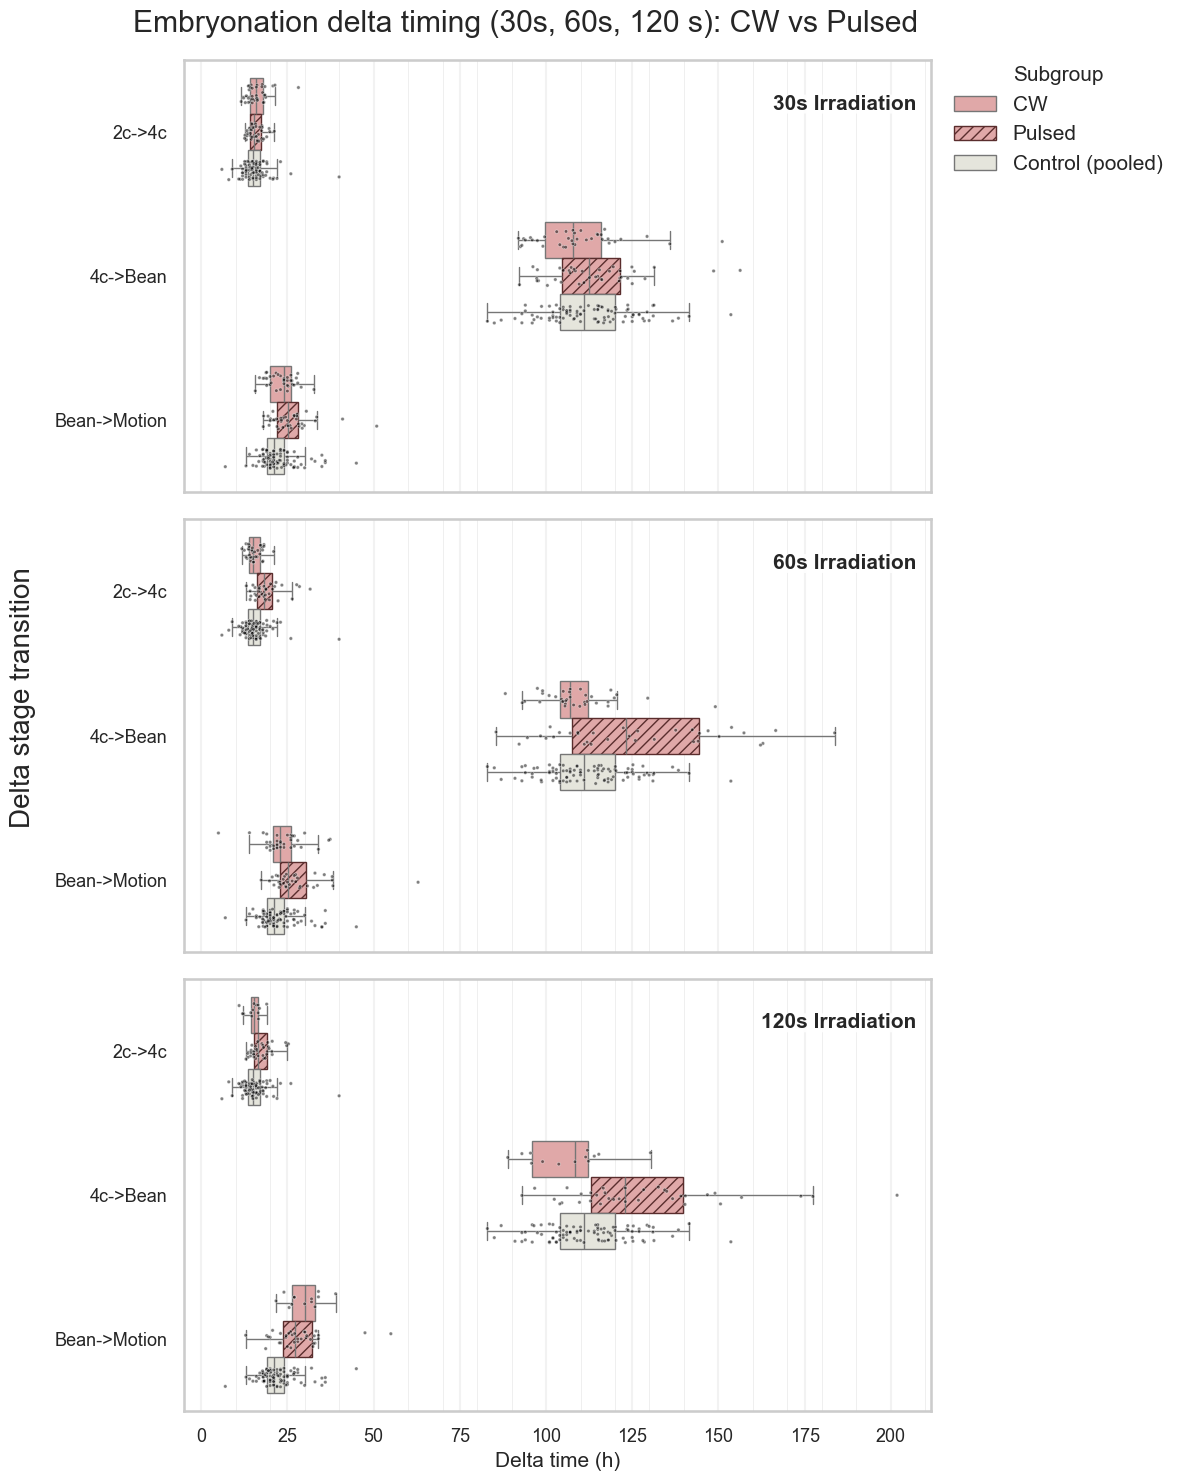

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/plots/boxplot_facets_delta_30s_60s_120s_cw_pulsed_control_pooled.png


In [27]:
# Vertical faceted grouped boxplots of delta-stage timing across three irradiation durations (30s, 60s, 120s), comparing CW, Pulsed, and pooled controls

fig_caption_delta_faceted_boxplots_30_60_120 = (
    "Figure: Vertical faceted grouped boxplots of delta-stage timing across three irradiation durations "
    "(30s, 60s, 120s), comparing CW, Pulsed, and pooled controls. Each facet corresponds to one duration "
    "(30s Irradiation, 60s Irradiation, 120s Irradiation) and uses a shared x-axis for direct comparison. "
    "The x-axis shows elapsed time in hours between consecutive developmental stages (delta_h), and the "
    "y-axis shows transition stage (2c->4c, 4c->Bean, Bean->Motion). Within each transition stage, grouped "
    "boxplots summarize subgroup distributions (median, IQR, whiskers), and jittered points show individual "
    "eggs. CW and Pulsed intentionally share the same fill color, while Pulsed is distinguished by diagonal "
    "hatching. Pooled controls combine control dates 2024-03-04, 2024-03-20, and 2025-06-12."
)
print(fig_caption_delta_faceted_boxplots_30_60_120)

try:
    delta_800nm_table_df
except NameError:
    raise ValueError("Run the previous delta-table cell first.")

delta_stage_map = {
    "delta_2c_4c": "2c->4c",
    "delta_4c_bean": "4c->Bean",
    "delta_bean_move": "Bean->Motion",
}
delta_stage_order = ["2c->4c", "4c->Bean", "Bean->Motion"]
facet_order = ["30s", "60s", "120s"]
facet_title_map = {
    "30s": "30s Irradiation",
    "60s": "60s Irradiation",
    "120s": "120s Irradiation",
}
subgroup_order = ["cw", "pulsed", "pooled control"]

box_palette = {
    "cw": "#e99f9f",
    "pulsed": "#e99f9f",
    "pooled control": "#e6e6db",
}
point_palette = {
    "cw": "#000000",
    "pulsed": "#000000",
    "pooled control": "#000000",
}

plot_frames = []
for dur in [30, 60, 120]:
    dur_label = f"{dur}s"
    sub = delta_800nm_table_df[
        (delta_800nm_table_df["group"].isin([f"cw_{dur}s", f"pulsed_{dur}s"]))
        | (delta_800nm_table_df["group"] == "pooled_control")
    ].copy()
    if sub.empty:
        continue

    sub["subgroup"] = np.where(
        sub["group"].str.startswith("cw_"),
        "cw",
        np.where(sub["group"].str.startswith("pulsed_"), "pulsed", "pooled control"),
    )
    sub["duration"] = dur_label
    plot_frames.append(sub)

if not plot_frames:
    raise ValueError("No data available for delta faceted plot.")

delta_plot_src = pd.concat(plot_frames, ignore_index=True)

delta_plot_long = (
    delta_plot_src.melt(
        id_vars=["egg_uid", "well_id", "duration", "subgroup"],
        value_vars=["delta_2c_4c", "delta_4c_bean", "delta_bean_move"],
        var_name="delta_stage",
        value_name="delta_h",
    )
    .dropna(subset=["delta_h"])
    .copy()
)

delta_plot_long["delta_stage"] = delta_plot_long["delta_stage"].map(delta_stage_map)
delta_plot_long["delta_stage"] = pd.Categorical(delta_plot_long["delta_stage"], categories=delta_stage_order, ordered=True)
delta_plot_long["duration"] = pd.Categorical(delta_plot_long["duration"], categories=facet_order, ordered=True)
delta_plot_long["subgroup"] = pd.Categorical(delta_plot_long["subgroup"], categories=subgroup_order, ordered=True)

fig, axes = plt.subplots(len(facet_order), 1, figsize=(12, 16), sharex=True)
if len(facet_order) == 1:
    axes = [axes]

legend_handles = None
legend_labels = None

for ax, dur_label in zip(axes, facet_order):
    sub = delta_plot_long[delta_plot_long["duration"] == dur_label].copy()

    sns.boxplot(
        data=sub,
        x="delta_h",
        y="delta_stage",
        hue="subgroup",
        order=delta_stage_order,
        hue_order=subgroup_order,
        palette=box_palette,
        showfliers=False,
        linewidth=1.0,
        width=0.75,
        ax=ax,
    )

    n_stage = len(delta_stage_order)
    n_hue = len(subgroup_order)
    pulsed_idx = subgroup_order.index("pulsed")
    expected_boxes = n_stage * n_hue
    box_patches = ax.patches[:expected_boxes]

    start = pulsed_idx * n_stage
    end = min(start + n_stage, len(box_patches))
    for patch in box_patches[start:end]:
        patch.set_hatch("///")
        patch.set_edgecolor("#5a2d2d")
        patch.set_linewidth(1.0)

    sns.stripplot(
        data=sub,
        x="delta_h",
        y="delta_stage",
        hue="subgroup",
        order=delta_stage_order,
        hue_order=subgroup_order,
        palette=point_palette,
        dodge=True,
        jitter=0.2,
        size=2.5,
        alpha=0.5,
        linewidth=0.5,
        edgecolor="white",
        ax=ax,
    )

    ax.text(
        0.98,
        0.92,
        facet_title_map[dur_label],
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=15,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.0",
            "facecolor": "white",
            "edgecolor": "#0C0C0C",
            "linewidth": 0.0,
            "alpha": 0.9,
        },
    )

    ax.set_title("")
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(axis="x", alpha=0.25)
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

    handles, labels = ax.get_legend_handles_labels()
    if legend_handles is None and legend_labels is None:
        seen = set()
        uniq_h = []
        uniq_l = []
        for h, l in zip(handles, labels):
            if l in seen:
                continue
            seen.add(l)
            uniq_h.append(h)
            uniq_l.append(l)
        legend_handles, legend_labels = uniq_h, uniq_l

    if ax.get_legend() is not None:
        ax.get_legend().remove()

axes[-1].set_xlabel("Delta time (h)", fontsize=15)
for ax in axes[:-1]:
    ax.set_xlabel("")

if len(delta_plot_long) > 0:
    xmin = float(delta_plot_long["delta_h"].min())
    xmax = float(delta_plot_long["delta_h"].max())
    pad = max(2.0, 0.05 * (xmax - xmin))
    for ax in axes:
        ax.set_xlim(xmin - pad, xmax + pad)

fig.supylabel("Delta stage transition", x=0.07, fontsize=20)

if legend_handles is not None:
    legend_label_map = {
        "cw": "CW",
        "pulsed": "Pulsed",
        "pooled control": "Control (pooled)",
    }
    display_labels = [legend_label_map.get(lbl, lbl) for lbl in legend_labels]

    for h, l in zip(legend_handles, legend_labels):
        if l == "pulsed" and hasattr(h, "set_hatch"):
            h.set_hatch("///")
            h.set_edgecolor("#5a2d2d")
            h.set_linewidth(1.0)

    fig.legend(
        legend_handles,
        display_labels,
        title="Subgroup",
        loc="upper left",
        bbox_to_anchor=(0.85, 0.9),
        frameon=False,
        fontsize=15,
        title_fontsize=15,
        borderaxespad=0.0,
    )

fig.suptitle("Embryonation delta timing (30s, 60s, 120 s): CW vs Pulsed", y=0.93)
plt.tight_layout(rect=[0.04, 0, 0.86, 0.95])
out_png = PLOTS_DIR / "boxplot_facets_delta_30s_60s_120s_cw_pulsed_control_pooled.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")


In [28]:
# Significance across cw/pulsed 30s, 60s, 120s, and pooled control within each delta group

from scipy import stats

alpha = 0.05
group_order = [
    "cw_30s",
    "pulsed_30s",
    "cw_60s",
    "pulsed_60s",
    "cw_120s",
    "pulsed_120s",
    "pooled_control",
]
delta_group_order = ["delta_2c_4c", "delta_4c_bean", "delta_bean_move"]


def p_to_sig(p: float) -> str:
    if np.isnan(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


if "delta_800nm_table_df" not in globals():
    raise ValueError("Run the delta table cell first.")

rows = []
for dcol in delta_group_order:
    groups = [
        delta_800nm_table_df.loc[delta_800nm_table_df["group"] == g, dcol].dropna().to_numpy(dtype=float)
        for g in group_order
    ]
    sizes = {g: len(arr) for g, arr in zip(group_order, groups)}

    normality_p = {}
    all_groups_normal = True
    for g, arr in zip(group_order, groups):
        if len(arr) < 3:
            normality_p[g] = np.nan
            all_groups_normal = False
            continue
        p_norm = float(stats.shapiro(arr).pvalue)
        normality_p[g] = p_norm
        if p_norm < alpha:
            all_groups_normal = False

    if any(len(arr) == 0 for arr in groups):
        test_name = "NA"
        test_stat = np.nan
        p_value = np.nan
    elif all_groups_normal:
        test_name = "ANOVA"
        tst = stats.f_oneway(*groups)
        test_stat = float(tst.statistic)
        p_value = float(tst.pvalue)
    else:
        test_name = "Kruskal-Wallis"
        tst = stats.kruskal(*groups)
        test_stat = float(tst.statistic)
        p_value = float(tst.pvalue)

    row = {
        "delta_group": dcol,
        "all_groups_normal": bool(all_groups_normal),
        "selected_test": test_name,
        "test_statistic": test_stat,
        "p_value": p_value,
        "significant_0.05": bool(np.isfinite(p_value) and p_value < alpha),
        "sig": p_to_sig(p_value),
    }
    for g in group_order:
        row[f"n_{g}"] = sizes.get(g, 0)
        row[f"normality_p_{g}"] = normality_p.get(g, np.nan)
    rows.append(row)

stats_delta_800nm_omnibus_df = pd.DataFrame(rows)
stats_delta_800nm_omnibus_df["delta_group"] = pd.Categorical(
    stats_delta_800nm_omnibus_df["delta_group"],
    categories=delta_group_order,
    ordered=True,
)
stats_delta_800nm_omnibus_df = stats_delta_800nm_omnibus_df.sort_values("delta_group").reset_index(drop=True)

display(stats_delta_800nm_omnibus_df)

out_csv = TABLES_DIR / "delta_800nm_omnibus_stats_all_groups.csv"
stats_delta_800nm_omnibus_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,delta_group,all_groups_normal,selected_test,test_statistic,p_value,significant_0.05,sig,n_cw_30s,normality_p_cw_30s,n_pulsed_30s,...,n_cw_60s,normality_p_cw_60s,n_pulsed_60s,normality_p_pulsed_60s,n_cw_120s,normality_p_cw_120s,n_pulsed_120s,normality_p_pulsed_120s,n_pooled_control,normality_p_pooled_control
0,delta_2c_4c,False,Kruskal-Wallis,35.0983,4.1245e-06,True,***,37,0.0004,39,...,36,0.1510,34,2.6435e-03,13,0.5568,35,0.0132,93,2.3960e-10
1,delta_4c_bean,False,Kruskal-Wallis,33.8156,7.3020e-06,True,***,37,0.0105,39,...,36,0.0047,34,2.6051e-01,13,0.5660,35,0.0166,93,7.6945e-01
2,delta_bean_move,False,Kruskal-Wallis,51.5230,2.3255e-09,True,***,37,0.7273,39,...,36,0.0219,34,8.3704e-06,13,0.8559,35,0.0022,93,3.8099e-06


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/delta_800nm_omnibus_stats_all_groups.csv


In [29]:
# Post-hoc tests for delta groups with significant omnibus difference

from scipy import stats

alpha = 0.05
group_order = [
    "cw_30s",
    "pulsed_30s",
    "cw_60s",
    "pulsed_60s",
    "cw_120s",
    "pulsed_120s",
    "pooled_control",
]
contrast_groups = [
    "cw_30s",
    "pulsed_30s",
    "cw_60s",
    "pulsed_60s",
    "cw_120s",
    "pulsed_120s",
]
control_group = "pooled_control"


def holm_adjust(pvals: np.ndarray) -> np.ndarray:
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        candidate = pvals[idx] * (m - rank)
        running = max(running, candidate)
        adj[idx] = min(running, 1.0)
    return adj


def p_to_sig(p: float) -> str:
    if np.isnan(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def dunn_pair_contrast(groups: dict[str, np.ndarray], g1: str, g2: str) -> tuple[float, float]:
    arrays = [groups[g] for g in group_order]
    values = np.concatenate(arrays)
    n_total = len(values)

    if n_total < 2 or len(groups[g1]) == 0 or len(groups[g2]) == 0:
        return np.nan, np.nan

    group_ids = np.concatenate([np.full(len(groups[g]), i) for i, g in enumerate(group_order)])
    ranks = stats.rankdata(values, method="average")

    _, tie_counts = np.unique(values, return_counts=True)
    tie_c = 1.0 - float(np.sum(tie_counts ** 3 - tie_counts) / (n_total ** 3 - n_total))
    if tie_c <= 0 or not np.isfinite(tie_c):
        return np.nan, np.nan

    mean_ranks = {}
    for i, g in enumerate(group_order):
        arr = groups[g]
        if len(arr) == 0:
            mean_ranks[g] = np.nan
        else:
            mean_ranks[g] = float(np.mean(ranks[group_ids == i]))

    n1 = len(groups[g1])
    n2 = len(groups[g2])
    denom = np.sqrt((n_total * (n_total + 1) / 12.0) * tie_c * (1.0 / n1 + 1.0 / n2))
    if denom == 0 or not np.isfinite(denom):
        return np.nan, np.nan

    z = (mean_ranks[g1] - mean_ranks[g2]) / denom
    p = float(2 * stats.norm.sf(abs(z)))
    return float(z), p


if "stats_delta_800nm_omnibus_df" not in globals():
    raise ValueError("Run the omnibus delta significance cell first.")
if "delta_800nm_table_df" not in globals():
    raise ValueError("Run the delta table cell first.")

sig_targets = stats_delta_800nm_omnibus_df[
    stats_delta_800nm_omnibus_df["significant_0.05"]
    & stats_delta_800nm_omnibus_df["selected_test"].isin(["ANOVA", "Kruskal-Wallis"])
][["delta_group", "selected_test"]].copy()

rows = []
for _, r in sig_targets.iterrows():
    dcol = r["delta_group"]
    omnibus_test = r["selected_test"]

    groups = {
        g: delta_800nm_table_df.loc[delta_800nm_table_df["group"] == g, dcol].dropna().to_numpy(dtype=float)
        for g in group_order
    }

    raw_ps = []
    raw_zs = []
    names = []
    ns = []
    for g in contrast_groups:
        z, p_raw = dunn_pair_contrast(groups, g, control_group)
        raw_zs.append(z)
        raw_ps.append(p_raw)
        names.append(f"{g} vs {control_group}")
        ns.append((len(groups[g]), len(groups[control_group])))

    raw_ps_arr = np.array(raw_ps, dtype=float)
    valid = np.isfinite(raw_ps_arr)
    p_adj = np.full_like(raw_ps_arr, np.nan)
    if valid.any():
        p_adj[valid] = holm_adjust(raw_ps_arr[valid])

    for comp, (n1, n2), z, p_raw, p_holm in zip(names, ns, raw_zs, raw_ps, p_adj):
        rows.append(
            {
                "delta_group": dcol,
                "omnibus_test": omnibus_test,
                "posthoc_test": "Dunn + Holm (vs pooled_control)",
                "comparison": comp,
                "n_group1": int(n1),
                "n_group2": int(n2),
                "statistic": z,
                "p_raw": p_raw,
                "p_adjusted": float(p_holm) if np.isfinite(p_holm) else np.nan,
                "significant_0.05": bool(np.isfinite(p_holm) and p_holm < alpha),
                "sig": p_to_sig(float(p_holm) if np.isfinite(p_holm) else np.nan),
            }
        )

stats_delta_800nm_posthoc_df = pd.DataFrame(rows)
if not stats_delta_800nm_posthoc_df.empty:
    stats_delta_800nm_posthoc_df = stats_delta_800nm_posthoc_df.sort_values(
        ["delta_group", "comparison"]
    ).reset_index(drop=True)

pd.set_option("display.precision", 4)
display(stats_delta_800nm_posthoc_df)

out_csv = TABLES_DIR / "delta_800nm_posthoc_stats_vs_pooled_control.csv"
stats_delta_800nm_posthoc_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,delta_group,omnibus_test,posthoc_test,comparison,n_group1,n_group2,statistic,p_raw,p_adjusted,significant_0.05,sig
0,delta_2c_4c,Kruskal-Wallis,Dunn + Holm (vs pooled_control),cw_120s vs pooled_control,13,93,-0.0464,9.6302e-01,1.0000e+00,False,ns
1,delta_2c_4c,Kruskal-Wallis,Dunn + Holm (vs pooled_control),cw_30s vs pooled_control,37,93,1.1085,2.6766e-01,1.0000e+00,False,ns
2,delta_2c_4c,Kruskal-Wallis,Dunn + Holm (vs pooled_control),cw_60s vs pooled_control,36,93,-0.0749,9.4033e-01,1.0000e+00,False,ns
3,delta_2c_4c,Kruskal-Wallis,Dunn + Holm (vs pooled_control),pulsed_120s vs pooled_control,35,93,3.4570,5.4623e-04,2.7312e-03,True,**
4,delta_2c_4c,Kruskal-Wallis,Dunn + Holm (vs pooled_control),pulsed_30s vs pooled_control,39,93,0.7169,4.7341e-01,1.0000e+00,False,ns
5,delta_2c_4c,Kruskal-Wallis,Dunn + Holm (vs pooled_control),pulsed_60s vs pooled_control,34,93,4.9463,7.5635e-07,4.5381e-06,True,***
6,delta_4c_bean,Kruskal-Wallis,Dunn + Holm (vs pooled_control),cw_120s vs pooled_control,13,93,-1.5373,1.2421e-01,4.4456e-01,False,ns
7,delta_4c_bean,Kruskal-Wallis,Dunn + Holm (vs pooled_control),cw_30s vs pooled_control,37,93,-1.3624,1.7308e-01,4.4456e-01,False,ns
8,delta_4c_bean,Kruskal-Wallis,Dunn + Holm (vs pooled_control),cw_60s vs pooled_control,36,93,-1.5931,1.1114e-01,4.4456e-01,False,ns
9,delta_4c_bean,Kruskal-Wallis,Dunn + Holm (vs pooled_control),pulsed_120s vs pooled_control,35,93,3.5296,4.1615e-04,2.4969e-03,True,**


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/delta_800nm_posthoc_stats_vs_pooled_control.csv


In [30]:
# Time differences (hours) for significant Dunn post-hoc comparisons vs pooled control

if "stats_delta_800nm_posthoc_df" not in globals():
    raise ValueError("Run the post-hoc delta cell first.")
if "delta_800nm_table_df" not in globals():
    raise ValueError("Run the delta table cell first.")

sig_posthoc = stats_delta_800nm_posthoc_df[
    (stats_delta_800nm_posthoc_df["significant_0.05"])
    & (stats_delta_800nm_posthoc_df["comparison"].str.endswith("vs pooled_control"))
].copy()

rows = []
for _, r in sig_posthoc.iterrows():
    dcol = r["delta_group"]
    comparison = r["comparison"]
    treatment_group, control_group = comparison.split(" vs ")

    g_treat = delta_800nm_table_df.loc[
        delta_800nm_table_df["group"] == treatment_group, dcol
    ].dropna().to_numpy(dtype=float)
    g_ctrl = delta_800nm_table_df.loc[
        delta_800nm_table_df["group"] == control_group, dcol
    ].dropna().to_numpy(dtype=float)

    if len(g_treat) == 0 or len(g_ctrl) == 0:
        continue

    median_treat = float(np.median(g_treat))
    median_ctrl = float(np.median(g_ctrl))
    mean_treat = float(np.mean(g_treat))
    mean_ctrl = float(np.mean(g_ctrl))
    sd_treat = float(np.std(g_treat, ddof=1)) if len(g_treat) > 1 else np.nan
    sd_ctrl = float(np.std(g_ctrl, ddof=1)) if len(g_ctrl) > 1 else np.nan

    rows.append(
        {
            "delta_group": dcol,
            "comparison": comparison,
            "n_treatment": int(len(g_treat)),
            "n_pooled_control": int(len(g_ctrl)),
            "median_treatment_h": median_treat,
            "median_pooled_control_h": median_ctrl,
            "median_diff_h_(treatment-control)": median_treat - median_ctrl,
            "mean_treatment_h": mean_treat,
            "mean_pooled_control_h": mean_ctrl,
            "mean_diff_h_(treatment-control)": mean_treat - mean_ctrl,
            "sd_treatment_h": sd_treat,
            "sd_pooled_control_h": sd_ctrl,
            "sd_diff_indep_h": np.sqrt(sd_treat ** 2 + sd_ctrl ** 2) if np.isfinite(sd_treat) and np.isfinite(sd_ctrl) else np.nan,
            "p_adjusted": float(r["p_adjusted"]) if np.isfinite(r["p_adjusted"]) else np.nan,
            "sig": r["sig"],
        }
    )

stats_delta_800nm_sig_diffs_df = pd.DataFrame(rows)
if not stats_delta_800nm_sig_diffs_df.empty:
    stats_delta_800nm_sig_diffs_df = stats_delta_800nm_sig_diffs_df.sort_values(
        ["delta_group", "comparison"]
    ).reset_index(drop=True)
else:
    print("No significant post-hoc comparisons vs pooled_control found for 800nm delta groups.")

display(stats_delta_800nm_sig_diffs_df)

out_csv = TABLES_DIR / "delta_800nm_significant_posthoc_time_differences_vs_pooled_control.csv"
stats_delta_800nm_sig_diffs_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,delta_group,comparison,n_treatment,n_pooled_control,median_treatment_h,median_pooled_control_h,median_diff_h_(treatment-control),mean_treatment_h,mean_pooled_control_h,mean_diff_h_(treatment-control),sd_treatment_h,sd_pooled_control_h,sd_diff_indep_h,p_adjusted,sig
0,delta_2c_4c,pulsed_120s vs pooled_control,35,93,16.5,15.0,1.5,17.5029,15.5333,1.9695,3.1356,3.9021,5.0058,2.7312e-03,**
1,delta_2c_4c,pulsed_60s vs pooled_control,34,93,18.2,15.0,3.2,19.0324,15.5333,3.4990,4.3310,3.9021,5.8295,4.5381e-06,***
2,delta_4c_bean,pulsed_120s vs pooled_control,35,93,123.0,111.0,12.0,128.3314,112.3065,16.0250,23.7267,12.9576,27.0344,2.4969e-03,**
3,delta_bean_move,cw_120s vs pooled_control,13,93,30.0,21.0,9.0,29.6538,22.2473,7.4065,4.8757,5.4520,7.3141,1.6162e-05,***
4,delta_bean_move,pulsed_120s vs pooled_control,35,93,27.1,21.0,6.1,28.1114,22.2473,5.8641,7.7583,5.4520,9.4824,2.2765e-06,***
5,delta_bean_move,pulsed_30s vs pooled_control,39,93,25.1,21.0,4.1,25.9590,22.2473,3.7117,6.2216,5.4520,8.2724,6.2377e-04,***
6,delta_bean_move,pulsed_60s vs pooled_control,34,93,25.3,21.0,4.3,27.8324,22.2473,5.5850,8.2308,5.4520,9.8727,2.6505e-05,***


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/800nm/unembryonated/tables/delta_800nm_significant_posthoc_time_differences_vs_pooled_control.csv
